# Análise Exploratória de Dados (EDA)

O objetivo desta Análise Exploratória é compreender a estrutura, os padrões, os relacionamentos e possíveis anomalias presentes nos dados. Esse entendimento servirá de base para a etapa de feature engineering e para a construção da Analytical Base Table (ABT), que será utilizada no treinamento dos modelos de machine learning.

Carregando os arquivos em parquet e criação de uma função helper para ter uma visão geral do dataframe.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import yaml


def find_project_root(marker="DataPipeline/config.yml"):
    p = Path.cwd().resolve()

    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate

    raise FileNotFoundError(
        "Raiz do projeto não encontrada (DataPipeline/config.yml ausente)."
    )


# Carrega a configuração do projeto
PROJECT_ROOT = find_project_root()

with open(PROJECT_ROOT / "DataPipeline" / "config.yml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# Diretório da camada clean
CLEAN_DIR = PROJECT_ROOT / cfg["paths"]["clean_dir"]

# Carrega as tabelas sanitizadas
clean_files = cfg["data"]["clean_files"]

df_application = pd.read_parquet(CLEAN_DIR / clean_files["application"])
df_bureau = pd.read_parquet(CLEAN_DIR / clean_files["bureau"])
df_previous_application = pd.read_parquet(
    CLEAN_DIR / clean_files["previous_application"]
)

In [3]:
def resumo_inicial(df: pd.DataFrame, nome: str = "DataFrame") -> None:
    """
    Exibe um resumo inicial do DataFrame para dar suporte à EDA.

    Informações exibidas:
        - Dimensões
        - Informações das colunas
        - Estatísticas descritivas
    """

    print("=" * 80)
    print(f"RESUMO INICIAL - {nome.upper()}")
    print("=" * 80)

    # Dimensões
    linhas, colunas = df.shape
    print(f"\nDimensões: {linhas:,} linhas × {colunas} colunas")

    print("\n" + "-" * 80)
    print("Informações das colunas")
    print("-" * 80)
    df.info()

    print("\n" + "-" * 80)
    print("Estatísticas descritivas")
    print("-" * 80)
    display(df.describe(include="all").T)

O objetivo desta Análise Exploratória é compreender a estrutura, os padrões, os relacionamentos e possíveis anomalias presentes nos dados. Esse entendimento servirá de base para a etapa de feature engineering e para a construção da Analytical Base Table (ABT), que será utilizada no treinamento dos modelos de machine learning.

#  1. Analisando a base principal ```application_train```

In [4]:
resumo_inicial(df_application, "application")

RESUMO INICIAL - APPLICATION

Dimensões: 307,511 linhas × 122 colunas

--------------------------------------------------------------------------------
Informações das colunas
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float32(64), float64(2), int16(2), int32(1), int8(37), object(16)
memory usage: 130.5+ MB

--------------------------------------------------------------------------------
Estatísticas descritivas
--------------------------------------------------------------------------------


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,NaN,NaN,NaN,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,NaN,NaN,NaN,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE_GENDER,307511,3,F,202448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,307511,2,N,202924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,NaN,NaN,NaN,0.007,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,NaN,NaN,NaN,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,NaN,NaN,NaN,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,NaN,NaN,NaN,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [5]:
df_application.head().T

,0,1,2,3,4
SK_ID_CURR,100002,100003,100004,100006,100007
TARGET,1,0,0,0,0
NAME_CONTRACT_TYPE,Cash loans,Cash loans,Revolving loans,Cash loans,Cash loans
CODE_GENDER,M,F,M,F,M
FLAG_OWN_CAR,N,N,Y,N,N
...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,0.0,0.0,0.0,NaN,0.0
AMT_REQ_CREDIT_BUREAU_WEEK,0.0,0.0,0.0,NaN,0.0
AMT_REQ_CREDIT_BUREAU_MON,0.0,0.0,0.0,NaN,0.0
AMT_REQ_CREDIT_BUREAU_QRT,0.0,0.0,0.0,NaN,0.0


Cada linha representa uma solicitação de crédito realizada por um cliente. As colunas contêm informações sobre o perfil do solicitante, sua situação financeira, histórico de emprego, características do empréstimo solicitado e a variável alvo (TARGET), que indica se houve inadimplência.

## 1.1 Analisando o ```TARGET```: é adimplente ou inadimplente?

In [6]:
print(f"Clientes adimplentes (TARGET = 0): {(df_application['TARGET'] == 0).sum():,}")
print(f"Clientes inadimplentes (TARGET = 1): {(df_application['TARGET'] == 1).sum():,}")

Clientes adimplentes (TARGET = 0): 282,686
Clientes inadimplentes (TARGET = 1): 24,825


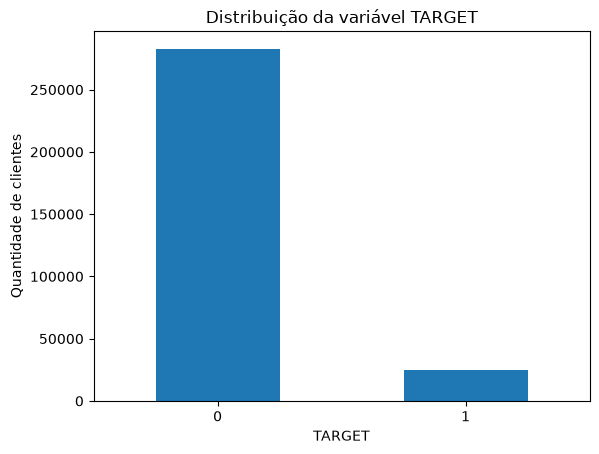

In [7]:
target_freq = (
    df_application["TARGET"]
    .value_counts()
    .rename_axis("TARGET")
    .to_frame("Quantidade")
)

target_freq["Percentual (%)"] = (
    df_application["TARGET"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_freq["Quantidade"].plot(kind="bar")

plt.title("Distribuição da variável TARGET")
plt.xlabel("TARGET")
plt.ylabel("Quantidade de clientes")
plt.xticks(rotation=0)

plt.show()

### Observações do ```TARGET```
* A maioria (~92%) dos clientes pertence à classe 0, indicando que não houve inadimplência.
* Isso caracteriza um problema de classificação desbalanceado, necessitando maior cautela na escolha de métricas de avaliação e aplicação de técnicas para lidar com esse desbalanceamento.

## 1.2 Variáveis Demográficas

Análise das principais características demográficas dos solicitantes: idade, gênero, escolaridade, estado civil, número de filhos, e tipo de renda.

In [8]:
demograficas = [
    "DAYS_BIRTH",
    "CODE_GENDER",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "CNT_CHILDREN",
    "NAME_INCOME_TYPE",
]

df_application[demograficas].head(15)

,DAYS_BIRTH,CODE_GENDER,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,CNT_CHILDREN,NAME_INCOME_TYPE
0,-9461,M,Secondary / secondary special,Single / not married,0,Working
1,-16765,F,Higher education,Married,0,State servant
2,-19046,M,Secondary / secondary special,Single / not married,0,Working
3,-19005,F,Secondary / secondary special,Civil marriage,0,Working
4,-19932,M,Secondary / secondary special,Single / not married,0,Working
5,-16941,M,Secondary / secondary special,Married,0,State servant
6,-13778,F,Higher education,Married,1,Commercial associate
7,-18850,M,Higher education,Married,0,State servant
8,-20099,F,Secondary / secondary special,Married,0,Pensioner
9,-14469,M,Secondary / secondary special,Single / not married,0,Working


In [9]:
# Verificar nulos 
df_application[demograficas].isna().sum().sort_values(ascending=False)

DAYS_BIRTH             0
CODE_GENDER            0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
CNT_CHILDREN           0
NAME_INCOME_TYPE       0
dtype: int64

In [10]:
# Transformar idade em dias para idade em anos

df_application["IDADE"] = (-df_application["DAYS_BIRTH"] / 365.25).round(1)

### 1.2.1 Idade (```DAYS_BIRTH``` transformado)

Perguntas a considerar:
1. Qual idade média?
2. Existem idades estranhas que solicitaram empréstimos? 
3. Como que a idade relaciona com o TARGET?

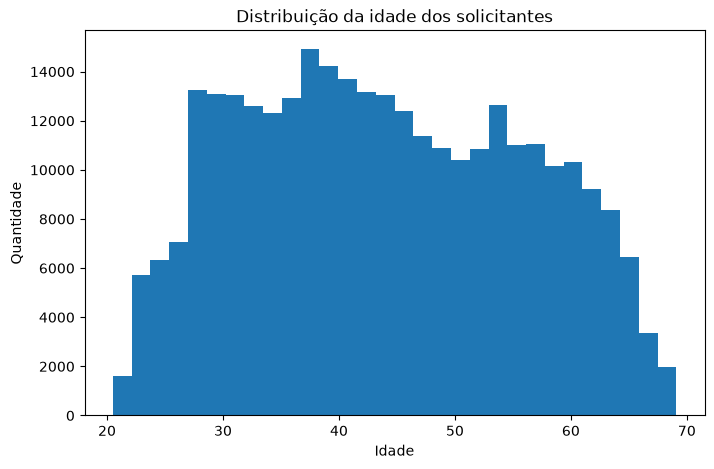

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df_application["IDADE"],
    bins=30
)

plt.title("Distribuição da idade dos solicitantes")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.show()

In [12]:
df_application.groupby("TARGET")["IDADE"].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282686.0,44.183969,11.948570,20.5,34.3,43.5,54.2,69.1
1,24825.0,40.752709,11.479462,21.0,31.2,39.1,49.4,68.9


In [13]:
df_application.groupby("TARGET")["IDADE"].median()

TARGET
0    43.5
1    39.1
Name: IDADE, dtype: float64

<Figure size 800x600 with 0 Axes>

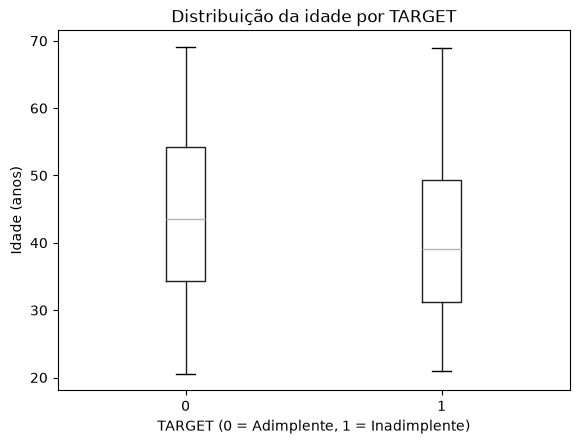

In [14]:
plt.figure(figsize=(8, 6))

df_application.boxplot(
    column="IDADE",
    by="TARGET",
    grid=False
)

plt.title("Distribuição da idade por TARGET")
plt.suptitle("")  # Remove o título automático do pandas
plt.xlabel("TARGET (0 = Adimplente, 1 = Inadimplente)")
plt.ylabel("Idade (anos)")

plt.show()

#### Observações
* Clientes inadimplentes apresentam média e mediana de idade menores. 
* Idade parece ser uma variável relevante para o modelo preditivo.

### 1.2.2 Gênero ```CODE_GENDER```

Perguntas a considerar:
1. Existe diferença na taxa de inadimplência entre homens e mulheres?

In [15]:
df_application["CODE_GENDER"].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [16]:
# Proporcionalidade
df_application["CODE_GENDER"].value_counts(normalize=True) * 100

CODE_GENDER
F      65.834393
M      34.164306
XNA     0.001301
Name: proportion, dtype: float64

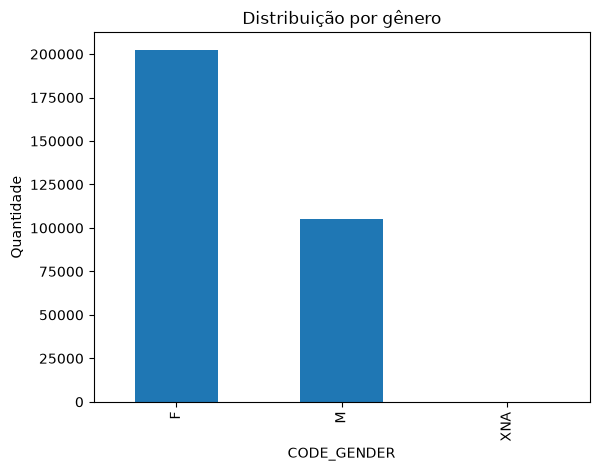

In [17]:
df_application["CODE_GENDER"].value_counts().plot.bar()

plt.title("Distribuição por gênero")
plt.ylabel("Quantidade")
plt.show()

In [18]:
genero_target = pd.crosstab(
    df_application["CODE_GENDER"],
    df_application["TARGET"],
    normalize="index"
).round(3)

genero_target

TARGET,0,1
CODE_GENDER,,
F,0.930,0.070
M,0.899,0.101
XNA,1.000,0.000


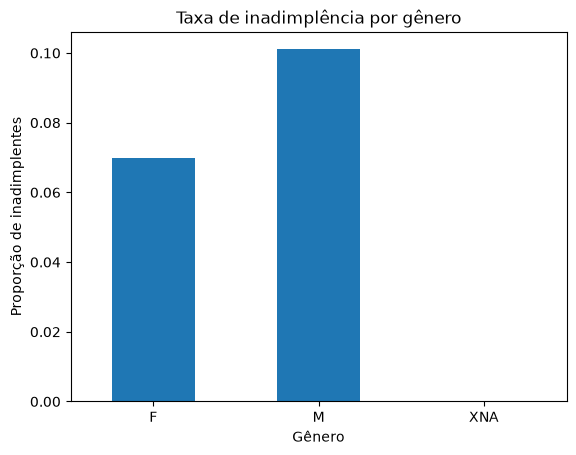

In [19]:
genero_target[1].plot(
    kind="bar"
)

plt.title("Taxa de inadimplência por gênero")
plt.xlabel("Gênero")
plt.ylabel("Proporção de inadimplentes")
plt.xticks(rotation=0)

plt.show()

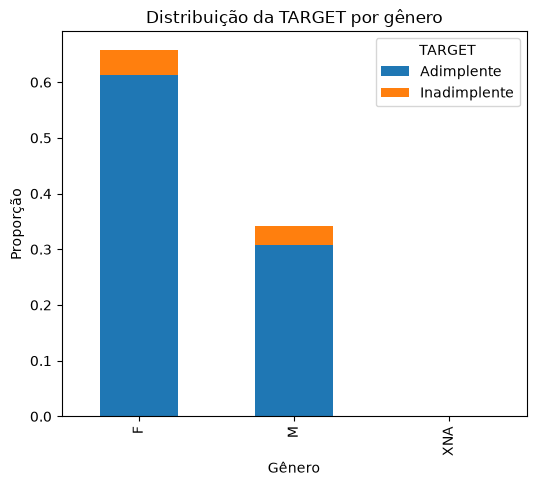

In [20]:
pd.crosstab(
    df_application["CODE_GENDER"],
    df_application["TARGET"],
    normalize="all"
).plot(
    kind="bar",
    stacked=True,
    figsize=(6,5)
)

plt.title("Distribuição da TARGET por gênero")
plt.xlabel("Gênero")
plt.ylabel("Proporção")

plt.legend(
    title="TARGET",
    labels=["Adimplente", "Inadimplente"]
)

plt.show()

#### Observações

* Há somente 4(0.001%) registros com clientes sem declaração de genêro (XNA), possibilidade de removê-los durante a construção da ABT. 
* Mulheres representam 65% dos solicitantes de crédito, mas apresentam uma taxa de inadimplência inferior à observada entre os homens (6.9% entre mulheres e 10.2% entre homens), indicando que a varíavel de gênero ```CODE_GENDER``` pode possuir poder preditivo para o modelo.

### 1.2.3 Escolaridade ```NAME_EDUCATION_TYPE```

Perguntas a considerar:
1. Escolaridade tem alguma relação com a taxa de inadimplência?|
2. Possui potencial para feature engineering?

In [21]:
df_application["NAME_EDUCATION_TYPE"].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

In [22]:
(
    df_application["NAME_EDUCATION_TYPE"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

NAME_EDUCATION_TYPE
Secondary / secondary special    71.02
Higher education                 24.34
Incomplete higher                 3.34
Lower secondary                   1.24
Academic degree                   0.05
Name: proportion, dtype: float64

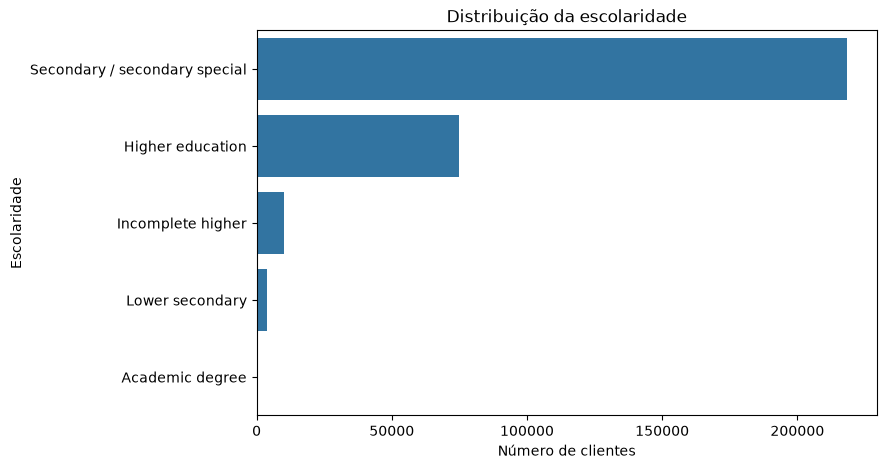

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_application,
    y="NAME_EDUCATION_TYPE",
    order=df_application["NAME_EDUCATION_TYPE"].value_counts().index
)

plt.title("Distribuição da escolaridade")
plt.xlabel("Número de clientes")
plt.ylabel("Escolaridade")

plt.show()

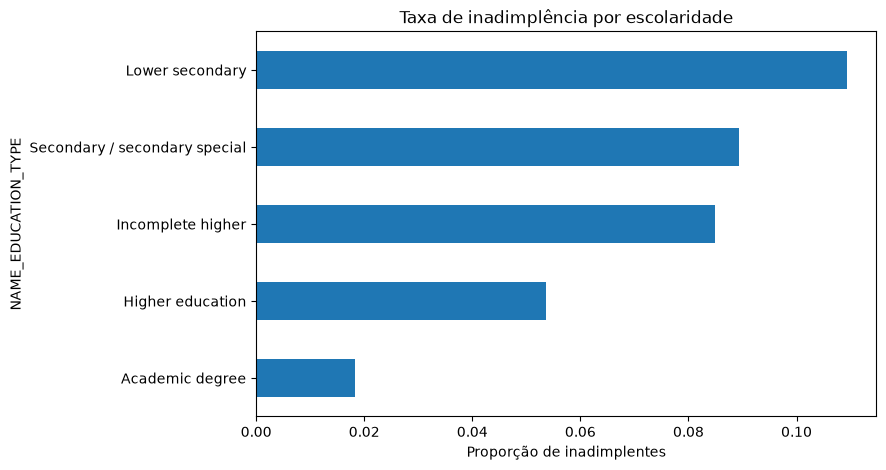

In [24]:
educacao_target = pd.crosstab(
    df_application["NAME_EDUCATION_TYPE"],
    df_application["TARGET"],
    normalize="index"
)

educacao_target[1].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Taxa de inadimplência por escolaridade")
plt.xlabel("Proporção de inadimplentes")

plt.show()

#### Observações

* 95% dos clientes da base possuem ensino secundário (71%) ou ensino superior (24%) indicando a concentração da carteira do grupo. Isso também indica dados desbalanceados no aspecto de educação.
* Observa-se uma possível tendência na taxa de inadimplência entre os níveis de escolaridade, sugerindo que essa variável possui potencial preditivo.
* Feature engineering: podemos considerar agrupamento (secundária, superior, outros) ou uma feature binária (possuí educação superior ou acima?)

### 1.2.4 Estado Civil ```NAME_FAMILY_STATUS```

In [25]:
df_application["NAME_FAMILY_STATUS"].value_counts()

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

In [26]:
(
    df_application["NAME_FAMILY_STATUS"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

NAME_FAMILY_STATUS
Married                 63.88
Single / not married    14.78
Civil marriage           9.68
Separated                6.43
Widow                    5.23
Unknown                  0.00
Name: proportion, dtype: float64

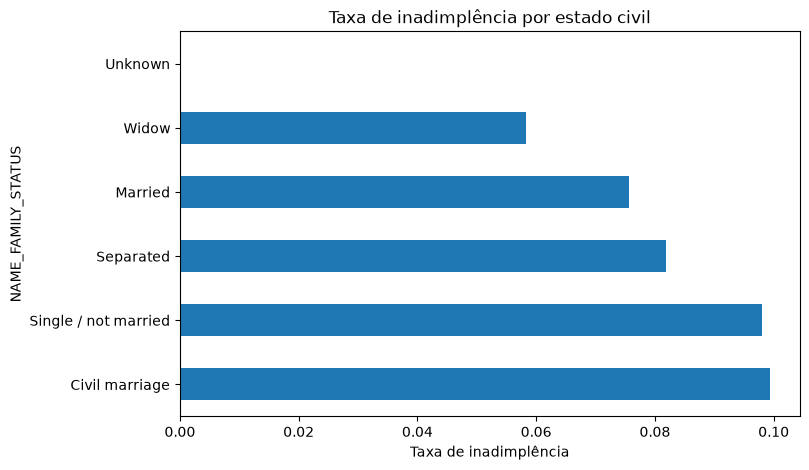

In [27]:
estado_civil = (
    df_application
    .groupby("NAME_FAMILY_STATUS", observed=False)["TARGET"]
    .mean()
    .sort_values(ascending=False)
)

estado_civil.plot(kind="barh", figsize=(8,5))

plt.title("Taxa de inadimplência por estado civil")
plt.xlabel("Taxa de inadimplência")

plt.show()

#### Observações

* Solteiros e uniões civis apresentam uma taxa de inadimplência elevada, indicando possível poder preditivo do modelo.
* A categoria ```unknown``` poderá ser excluida na ABT pois somente contém 2 observações.

### 1.2.5 Número de Filhos ```CNT_CHILDREN```

In [28]:
df_application["CNT_CHILDREN"].value_counts().sort_index()

CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
8          2
9          2
10         2
11         1
12         2
14         3
19         2
Name: count, dtype: int64

In [29]:
df_application["CNT_CHILDREN"].describe()

count    307511.000000
mean          0.417052
std           0.722121
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64

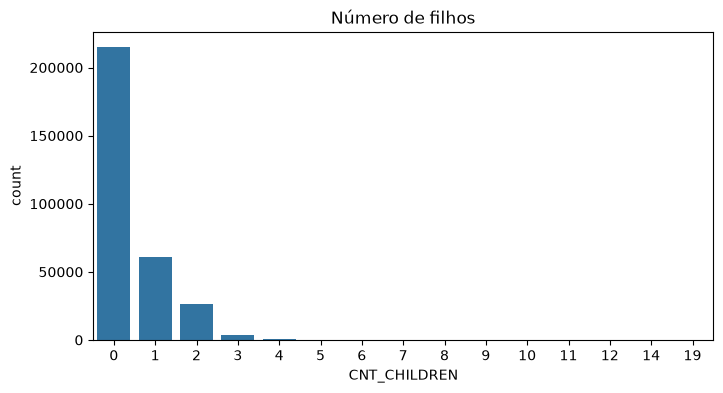

In [30]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df_application,
    x="CNT_CHILDREN"
)

plt.title("Número de filhos")

plt.show()

In [31]:
filhos = (
    df_application
    .groupby("CNT_CHILDREN", observed=False)["TARGET"]
    .agg(["count","mean"])
)

children_target = (
    df_application
    .groupby("CNT_CHILDREN", observed=False)["TARGET"]
    .agg(
        Clientes="count",
        Taxa_Inadimplencia="mean"
    )
)

children_target

,Clientes,Taxa_Inadimplencia
CNT_CHILDREN,,
0,215371,0.077118
1,61119,0.089236
2,26749,0.087218
3,3717,0.096314
4,429,0.128205
5,84,0.083333
6,21,0.285714
7,7,0.000000
8,2,0.000000


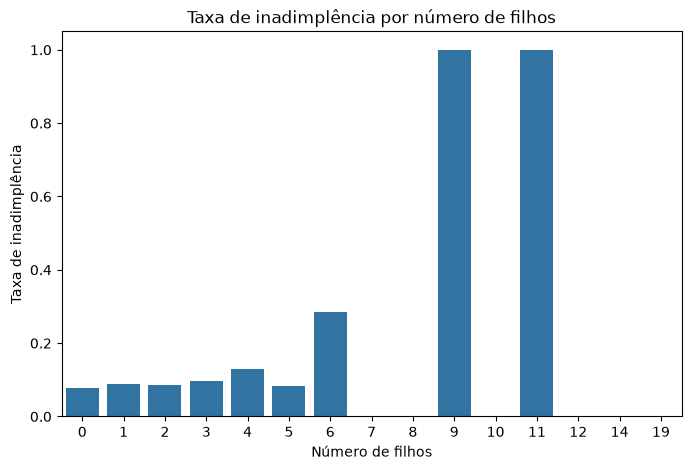

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=children_target.reset_index(),
    x="CNT_CHILDREN",
    y="Taxa_Inadimplencia"
)

plt.title("Taxa de inadimplência por número de filhos")
plt.xlabel("Número de filhos")
plt.ylabel("Taxa de inadimplência")

plt.show()

#### Observações

* A maioria dos clientes não possuem filhos (~70%)
* Há uma leve tendência no aumento da taxa de inadimplência entre clientes com um número maior de filhos, mas com poucas observações.
* Feature engineering: Podemos agrupar os valores altos que ocorrem raramente, para 4+ filhos.

### 1.2.6 Tipo de Renda ```NAME_INCOME_TYPE```

Perguntas a considerar:
1. Alguns tipos de renda apresentam maior risco? Algumas categorias tendem a ser mais inadimplentes?
2. O tipo de renda está relacionado ao valor da renda? - Cruzamento com a coluna a coluna de renda ```AMT_INCOME_TOTAL```
3. O tipo de renda realmente adiciona informação? Possível colinearidade com a quantidade de renda
4. Feature engineering

In [33]:
df_application["NAME_INCOME_TYPE"].value_counts()

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

In [34]:
(
    df_application["NAME_INCOME_TYPE"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

NAME_INCOME_TYPE
Working                 51.63
Commercial associate    23.29
Pensioner               18.00
State servant            7.06
Unemployed               0.01
Student                  0.01
Businessman              0.00
Maternity leave          0.00
Name: proportion, dtype: float64

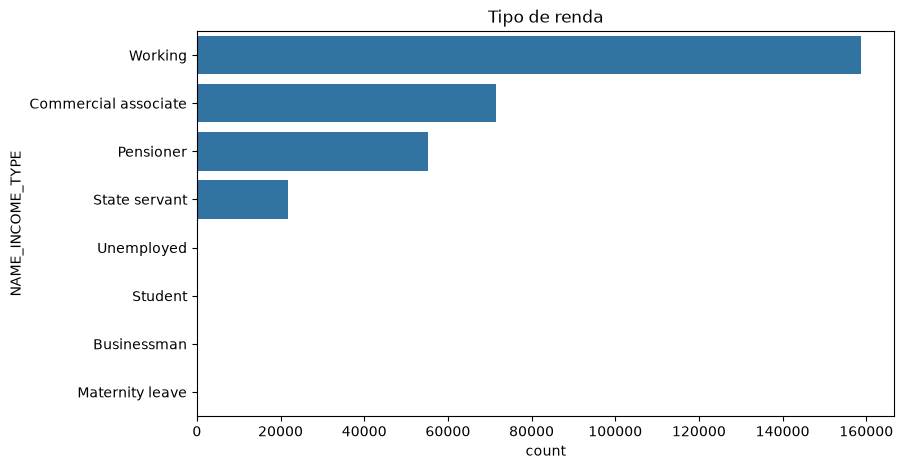

In [35]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df_application,
    y="NAME_INCOME_TYPE",
    order=df_application["NAME_INCOME_TYPE"].value_counts().index
)

plt.title("Tipo de renda")

plt.show()

In [36]:
income_type = (
    df_application
    .groupby("NAME_INCOME_TYPE", observed=False)["TARGET"]
    .mean()
    .sort_values(ascending=False)
)

income_type

NAME_INCOME_TYPE
Maternity leave         0.400000
Unemployed              0.363636
Working                 0.095885
Commercial associate    0.074843
State servant           0.057550
Pensioner               0.053864
Businessman             0.000000
Student                 0.000000
Name: TARGET, dtype: float64

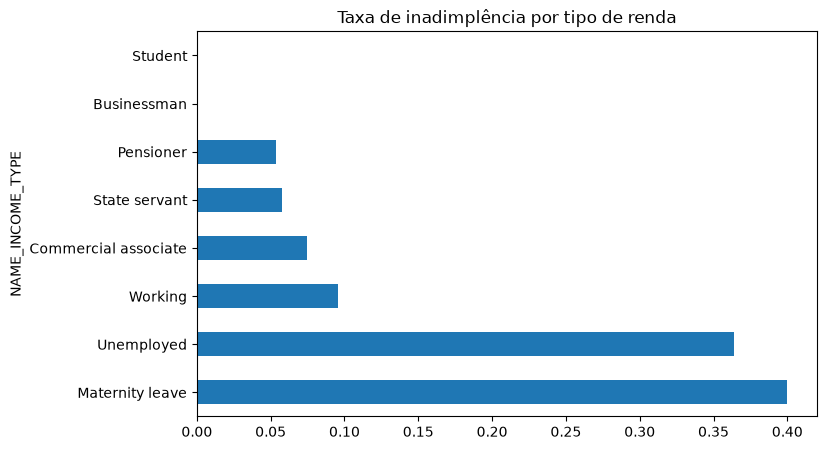

In [37]:
income_type.plot(kind="barh", figsize=(8,5))

plt.title("Taxa de inadimplência por tipo de renda")

plt.show()

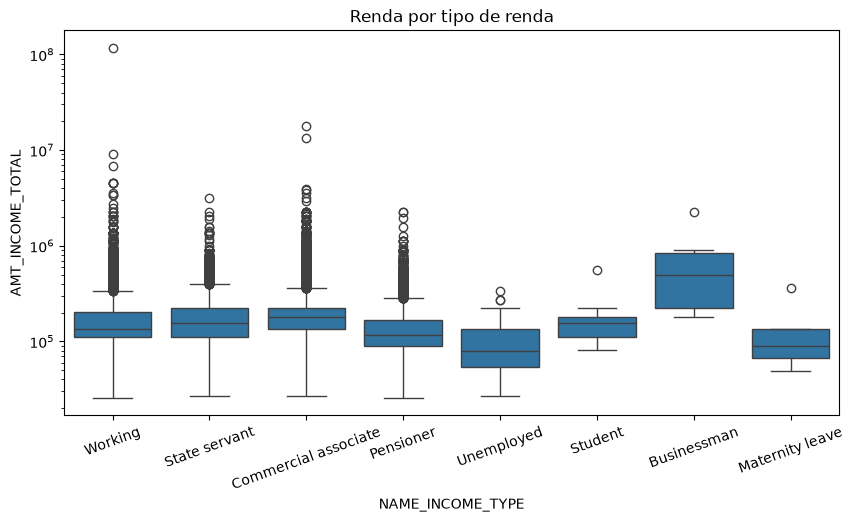

In [38]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_application,
    x="NAME_INCOME_TYPE",
    y="AMT_INCOME_TOTAL"
)

plt.yscale("log")
plt.xticks(rotation=20)

plt.title("Renda por tipo de renda")

plt.show()

#### Observações

* A maior parte dos clientes (51.6%) estão trabalhando ("Working"), indicando que é o principal perfil da carteira de crédito.
* Outras categorias também possuem representividade significativa.
* Apesar da alta taxa de inadimplência dos clientes em licença de maternidade e desempregados, aparecem com frequência extremamente baixa de <0.01%, junto com estudantes e empresários. 
* Clientes cuja principal fonte de renda é o trabalho assalariado apresentam comportamento diferente de grupos como pensionistas ou servidores públicos, indicando que o tipo de renda pode possuir poder de previsão para o modelo.

## 1.3 Variáveis Financeiras

As variáveis financeiras talvez sejam as mais fortes preditoras seguindo intuição. Todos contém somente valores númericos, e são candidatos para fazer feature engineering.

* Renda, valor do crédito, valor da anuidade, e o valor dos bens.

In [39]:
financeiras = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]

# 2 decimais e sem notação científica
pd.set_option('display.float_format', '{:.2f}'.format)

df_application[financeiras].head(10)

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
0,202500.00,406597.50,24700.50,351000.00
1,270000.00,1293502.50,35698.50,1129500.00
2,67500.00,135000.00,6750.00,135000.00
3,135000.00,312682.50,29686.50,297000.00
4,121500.00,513000.00,21865.50,513000.00
5,99000.00,490495.50,27517.50,454500.00
6,171000.00,1560726.00,41301.00,1395000.00
7,360000.00,1530000.00,42075.00,1530000.00
8,112500.00,1019610.00,33826.50,913500.00
9,135000.00,405000.00,20250.00,405000.00


In [40]:
df_application[financeiras].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.00,168797.92,237123.15,25650.00,112500.00,147150.00,202500.00,117000000.00
AMT_CREDIT,307511.00,599025.94,402490.78,45000.00,270000.00,513531.00,808650.00,4050000.00
AMT_ANNUITY,307499.00,27108.57,14493.74,1615.50,16524.00,24903.00,34596.00,258025.50
AMT_GOODS_PRICE,307233.00,538396.12,369446.47,40500.00,238500.00,450000.00,679500.00,4050000.00


In [41]:
print("Nulos:")
df_application[financeiras].isna().sum().sort_values(ascending=False)

Nulos:


AMT_GOODS_PRICE     278
AMT_ANNUITY          12
AMT_INCOME_TOTAL      0
AMT_CREDIT            0
dtype: int64

### 1.3.1 Renda ```AMT_INCOME_TOTAL```

Perguntas a considerar
1. Como a renda está distribuída?
2. Existem outliers? Como melhor lidar com elas?
3. A renda está associada à taxa de inadimplência?
4. Potencial para feature engineering usando essa variável

In [42]:
df_application["AMT_INCOME_TOTAL"].describe()

count      307511.00
mean       168797.92
std        237123.15
min         25650.00
25%        112500.00
50%        147150.00
75%        202500.00
max     117000000.00
Name: AMT_INCOME_TOTAL, dtype: float64

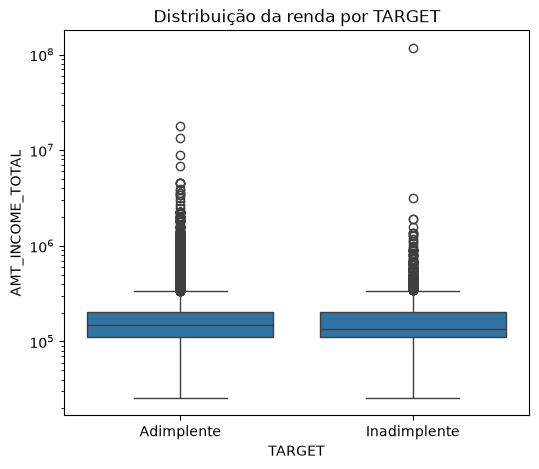

In [43]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_application,
    x="TARGET",
    y="AMT_INCOME_TOTAL"
)

plt.yscale("log")

plt.xticks([0,1], ["Adimplente", "Inadimplente"])

plt.title("Distribuição da renda por TARGET")

plt.show()

In [44]:
(
    df_application
    .groupby("TARGET")["AMT_INCOME_TOTAL"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282686.00,169077.72,110476.27,25650.00,112500.00,148500.00,202500.00,18000090.00
1,24825.00,165611.76,746676.96,25650.00,112500.00,135000.00,202500.00,117000000.00


In [45]:
income_bins = pd.qcut(
    df_application["AMT_INCOME_TOTAL"],
    q=10
)

(
    df_application
    .groupby(income_bins, observed=False)["TARGET"]
    .mean()
)

AMT_INCOME_TOTAL
(25649.999, 81000.0]      0.08
(81000.0, 99000.0]        0.08
(99000.0, 112500.0]       0.09
(112500.0, 135000.0]      0.08
(135000.0, 147150.0]      0.09
(147150.0, 162000.0]      0.09
(162000.0, 180000.0]      0.08
(180000.0, 225000.0]      0.08
(225000.0, 270000.0]      0.07
(270000.0, 117000000.0]   0.06
Name: TARGET, dtype: float64

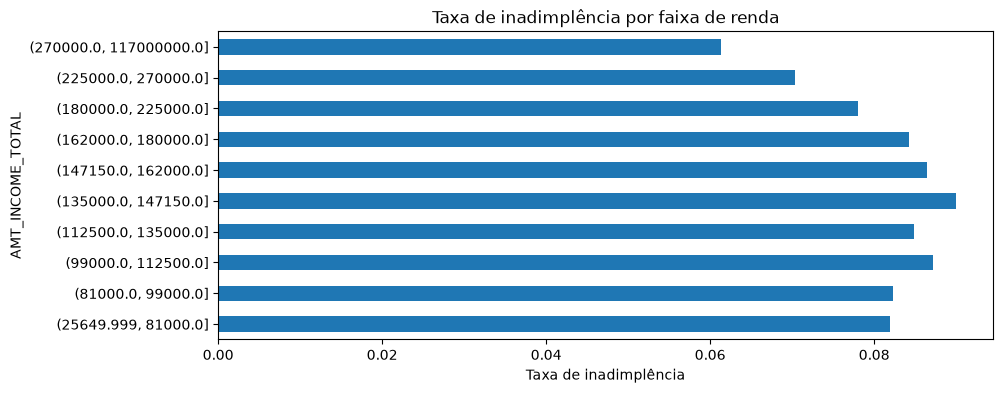

In [46]:
(
    df_application
    .groupby(income_bins, observed=False)["TARGET"]
    .mean()
).plot(
    kind="barh",
    figsize=(10,4)
)

plt.xlabel("Taxa de inadimplência")
plt.title("Taxa de inadimplência por faixa de renda")

plt.show()

In [47]:
df_application["AMT_INCOME_TOTAL"].quantile(0.99)

472500.0

#### Observações

* Foram identificados alguns outliers de renda, afetando medidas de média e dificultando a visualização. 
* A mediana seria melhor para representar a renda típica.
* Grande parte dos clientes estão concentradas em faixas de renda mais baixas: cauda longa à direita.
* Há uma diferença na distribuição de renda entre clientes adimplentes e inadimplentes sugerindo possibilidade de poder preditivo.
* Bom candidato para feature engineering com outras variáveis financeiras.

### 1.3.2 Valor do Crédito ```AMT_CREDIT```

O valor do empréstimo. 

Perguntas a considerar: 
1. Como o valor do crédito está distribuído?
2. Existem outliers?
3. Clientes inadimplentes tendem a solicitar créditos maiores ou menores?
4. Existe relação entre valor do crédito e renda?

In [48]:
df_application["AMT_CREDIT"].describe()

count    307511.00
mean     599025.94
std      402490.78
min       45000.00
25%      270000.00
50%      513531.00
75%      808650.00
max     4050000.00
Name: AMT_CREDIT, dtype: float64

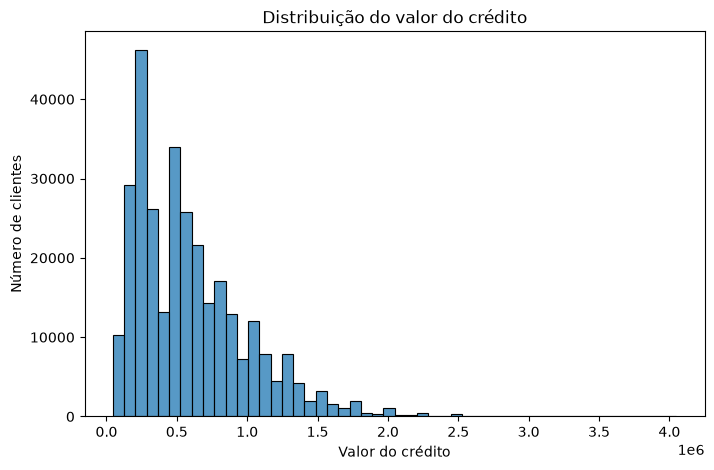

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_application,
    x="AMT_CREDIT",
    bins=50
)

plt.title("Distribuição do valor do crédito")
plt.xlabel("Valor do crédito")
plt.ylabel("Número de clientes")

plt.show()

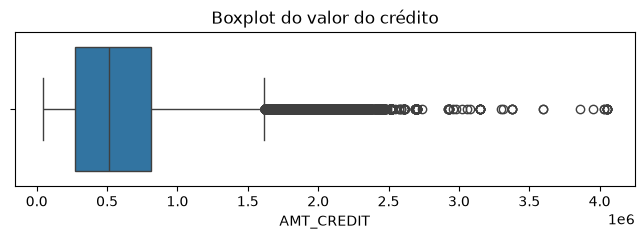

In [50]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df_application["AMT_CREDIT"]
)

plt.title("Boxplot do valor do crédito")

plt.show()

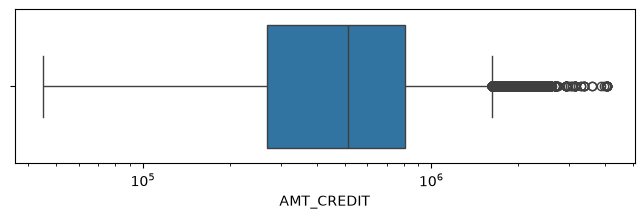

In [51]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df_application["AMT_CREDIT"]
)

plt.xscale("log")

plt.show()

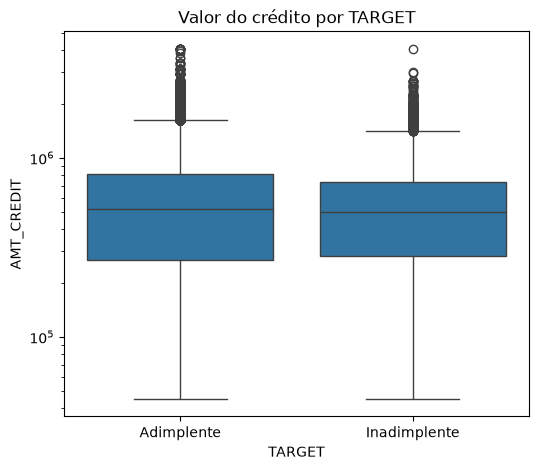

In [52]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_application,
    x="TARGET",
    y="AMT_CREDIT"
)

plt.yscale("log")

plt.xticks([0,1], ["Adimplente", "Inadimplente"])

plt.title("Valor do crédito por TARGET")

plt.show()

In [53]:
credit_bins = pd.qcut(
    df_application["AMT_CREDIT"],
    q=10,
    duplicates="drop"
)

default_credit = (
    df_application
    .groupby(credit_bins, observed=False)["TARGET"]
    .mean()
)

default_credit

AMT_CREDIT
(44999.999, 180000.0]    0.07
(180000.0, 254700.0]     0.08
(254700.0, 306306.0]     0.08
(306306.0, 432000.0]     0.10
(432000.0, 513531.0]     0.10
(513531.0, 604152.0]     0.11
(604152.0, 755190.0]     0.09
(755190.0, 900000.0]     0.07
(900000.0, 1133748.0]    0.07
(1133748.0, 4050000.0]   0.05
Name: TARGET, dtype: float64

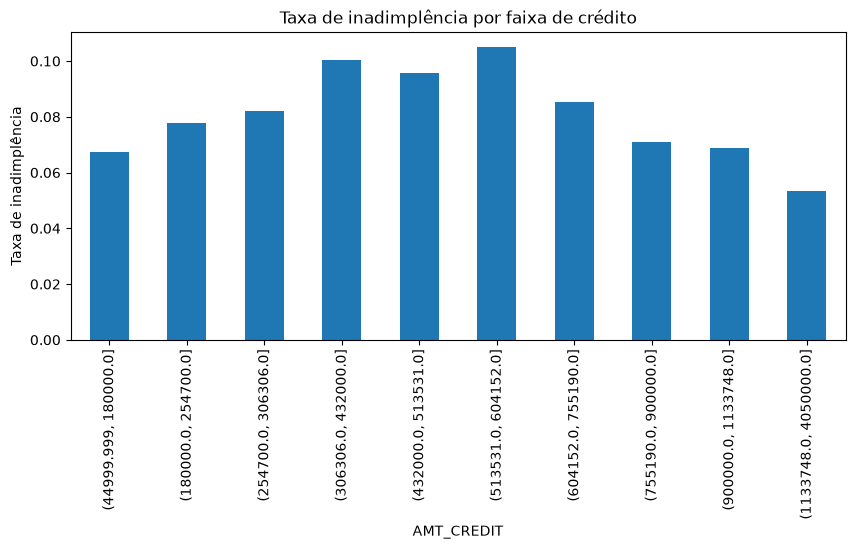

In [54]:
plt.figure(figsize=(10,4))

default_credit.plot(kind="bar")

plt.ylabel("Taxa de inadimplência")
plt.title("Taxa de inadimplência por faixa de crédito")

plt.show()

In [55]:
(
    df_application
    .groupby("TARGET")["AMT_CREDIT"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282686.00,602648.31,406845.91,45000.00,270000.00,517788.00,810000.00,4050000.00
1,24825.00,557778.50,346433.25,45000.00,284400.00,497520.00,733315.50,4027680.00


#### Observações

* A distribuição do valor do crédito está mais concentrada em valores menores.
* Presença de outliers, mas menos pronunciados do que na renda.
* Essa varíavel isoladamente parece não ter um poder preditivo significativo. 
* Feature engineering: excelente candidato para uma nova feature ```CREDIT_INCOME_RATIO = AMT_CREDIT / AMT_INCOME_TOTAL```

### 1.3.3 Valor da Anuidade ```AMT_ANNUITY```

As anuidades são os pagamentos que o cliente faz. O cliente não paga o empréstimo inteiro em uma vez.

In [56]:
df_application["AMT_ANNUITY"].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
AMT_ANNUITY,307499.00,27108.57,14493.74,1615.50,6182.91,9000.00,16524.00,24903.00,34596.00,53325.00,70006.50,258025.50


In [57]:
df_application["AMT_ANNUITY"].isna().mean() * 100

0.003902299429939092

In [58]:
matrix = df_application[financeiras].corr()
print(matrix)

                  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE
AMT_INCOME_TOTAL              1.00        0.16         0.19             0.16
AMT_CREDIT                    0.16        1.00         0.77             0.99
AMT_ANNUITY                   0.19        0.77         1.00             0.78
AMT_GOODS_PRICE               0.16        0.99         0.78             1.00


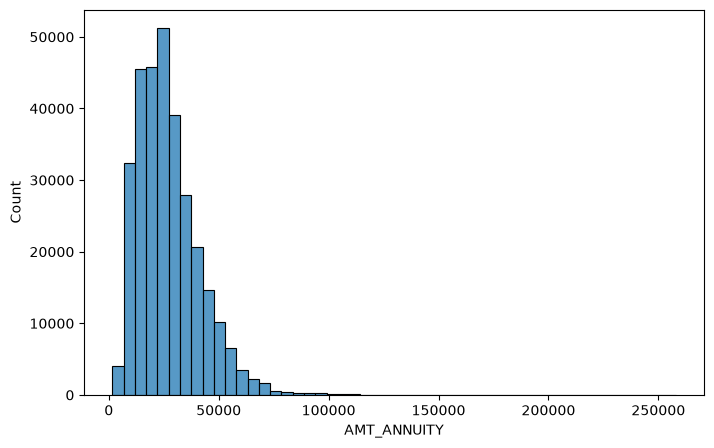

In [59]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_application,
    x="AMT_ANNUITY",
    bins=50
)

plt.show()

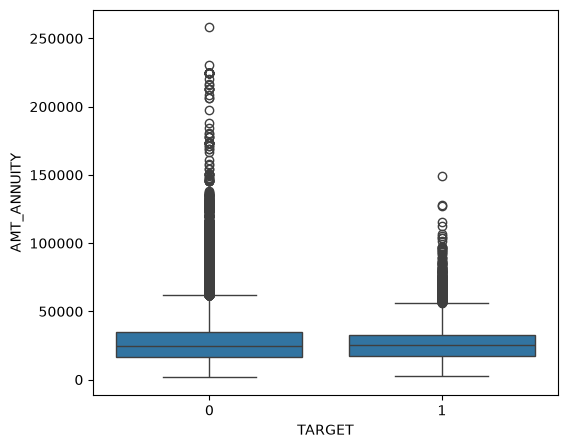

In [60]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_application,
    x="TARGET",
    y="AMT_ANNUITY"
)

plt.show()

In [61]:
df_application.groupby("TARGET")["AMT_ANNUITY"].agg(
    ["count","mean","median"]
)

,count,mean,median
TARGET,,,
0,282674,27163.62,24876.00
1,24825,26481.74,25263.00


#### Observações

* As anuidades seguem um padrão similar à do crédito, com uma correlação alta. A maioria dos dados estão concentrados em valores menores.
* Clientes adimplentes e inadimplentes apresentam distribuições semelhantes, indicando capacidade limitade de predição de clientes inadimplentes.
* 12 valores nulos, que podem ser tratados com imputação de mediana.

### 1.3.4 Valor dos Bens ```AMT_GOODS_PRICE```

O valor do bem financiado, complementando ```AMT_CREDIT``` e ```AMT_ANNUITY```. 

In [62]:
df_application["AMT_GOODS_PRICE"].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
AMT_GOODS_PRICE,307233.00,538396.12,369446.47,40500.00,67500.00,135000.00,238500.00,450000.00,679500.00,1305000.00,1800000.00,4050000.00


In [63]:
goodsprice_null_count = df_application["AMT_GOODS_PRICE"].isna().sum()

goodsprice_null_pct = df_application["AMT_GOODS_PRICE"].isna().mean() * 100

print(
    f"Quantidade de nulos: {goodsprice_null_count}\n"
    f"Percentual: {goodsprice_null_pct:.2f}%"
)

Quantidade de nulos: 278
Percentual: 0.09%


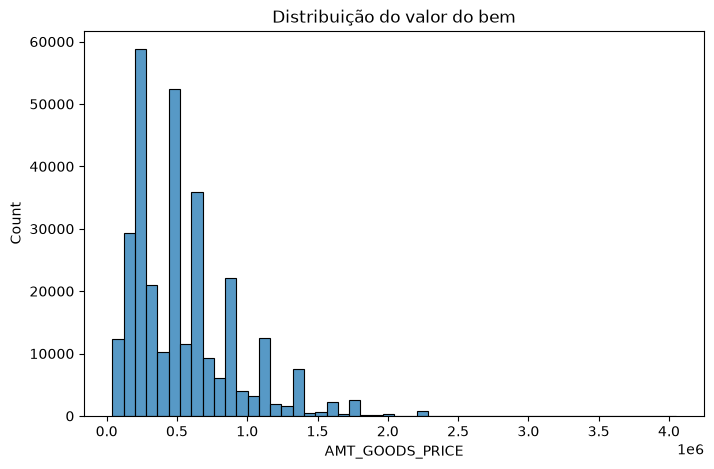

In [64]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_application,
    x="AMT_GOODS_PRICE",
    bins=50
)

plt.title("Distribuição do valor do bem")
plt.show()

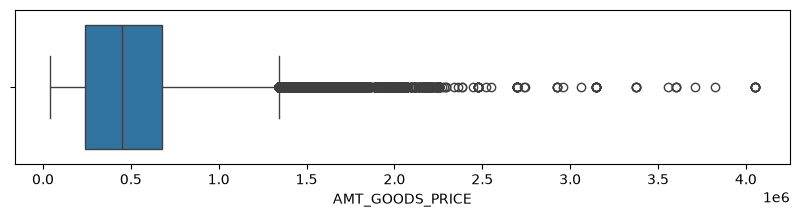

In [65]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df_application["AMT_GOODS_PRICE"]
)

plt.show()

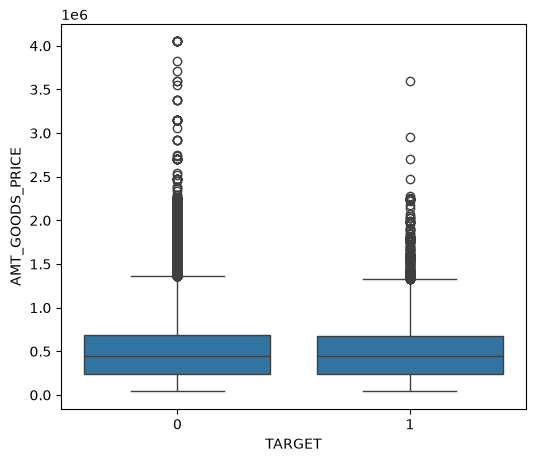

In [66]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_application,
    x="TARGET",
    y="AMT_GOODS_PRICE"
)

plt.show()

In [67]:
df_application.groupby("TARGET")["AMT_GOODS_PRICE"].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282429.00,542736.88,373785.50,40500.00,238500.00,450000.00,688500.00,4050000.00
1,24804.00,488972.44,311636.50,45000.00,238500.00,450000.00,675000.00,3600000.00


#### Observações

* Como as outras variáveis financeiras, esta distribuição também é fortemente assimétrica à direita, concentrando os financiamentos em bens de menor valor.
* Clientes adimplentes e inadimplentes apresentam distribuições semelhantes, indicando que essa variável isoladamente não tem um poder preditivo significativo.
* As medianas são iguais para clientes adimplentes e inadimplentes.
* As médias são elevadas para clientes adimplentes, possivelmente por causa dos outliers.

### 1.3.5 Possíveis Novas Features - Exploração

3 das 4 variáveis isoladamente indicaram baixo poder preditivo, mas são essênciais para o negócio pois são dados financeiros concretos.

##### 1.3.5.1 Credit to Income Ratio

A intuição é que valores altos indicariam um comprometimento financeiro maior e por isso talvez um risco maior de inadimplência.

In [68]:
df_application["CREDIT_INCOME_RATIO"] = (
    df_application["AMT_CREDIT"] /
    df_application["AMT_INCOME_TOTAL"]
)

In [69]:
df_application.groupby("TARGET")["CREDIT_INCOME_RATIO"].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282686.00,3.96,2.70,0.04,2.00,3.27,5.19,49.23
1,24825.00,3.89,2.63,0.00,2.13,3.25,4.99,84.74


<Axes: xlabel='TARGET', ylabel='CREDIT_INCOME_RATIO'>

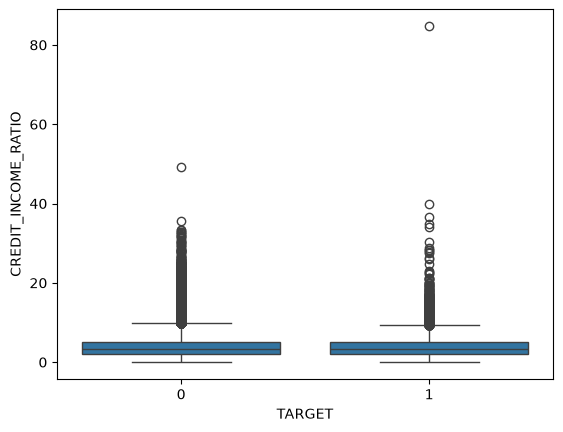

In [70]:
sns.boxplot(
    data=df_application,
    x="TARGET",
    y="CREDIT_INCOME_RATIO"
)

##### 1.3.5.2 Annuity to Income Ratio

Quanto da renda é necessária para pagar as parcelas. Representaria a capacidade de pagamento.

In [71]:
df_application["ANNUITY_INCOME_RATIO"] = (
    df_application["AMT_ANNUITY"] /
    df_application["AMT_INCOME_TOTAL"]
)

In [72]:
df_application.groupby("TARGET")["ANNUITY_INCOME_RATIO"].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282674.00,0.18,0.09,0.00,0.11,0.16,0.23,1.57
1,24825.00,0.19,0.09,0.00,0.12,0.17,0.23,1.88


<Axes: xlabel='TARGET', ylabel='ANNUITY_INCOME_RATIO'>

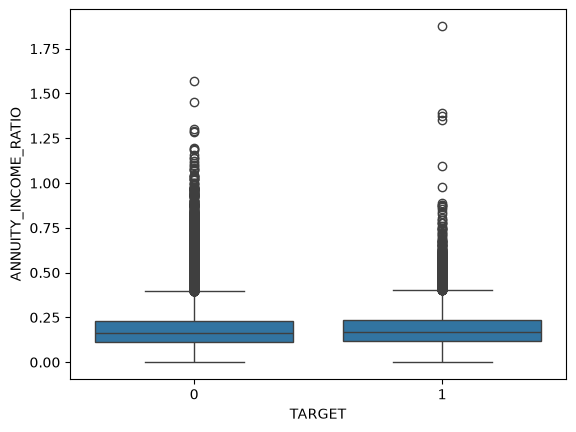

In [73]:
sns.boxplot(
    data=df_application,
    x="TARGET",
    y="ANNUITY_INCOME_RATIO",
)

##### 1.3.5.3 Credit to Goods Ratio

Mostra qual porcentagem do bem foi fnanciado. Alguns clientes podem dar um valor de entrada. Outros clientes que financiam 100% do bem podem apresentar um perfil mais arriscado.

In [74]:
df_application["CREDIT_GOODS_RATIO"] = (
    df_application["AMT_CREDIT"] /
    df_application["AMT_GOODS_PRICE"]
)

In [75]:
df_application.groupby("TARGET")["CREDIT_GOODS_RATIO"].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282429.00,1.12,0.12,0.15,1.00,1.12,1.20,6.00
1,24804.00,1.15,0.13,0.33,1.00,1.15,1.21,2.67


#### Resumo das Novas Features

1. Credit Income Ratio: Resultado surpreendente, os inadimplentes tiveram uma proporção menor de 3.86 (Credito / Renda) contra o 3.96 dos adimplentes. 
2. Annuity Income Ratio: Também um resultado surpresa. Os clientes adimplentes e inadimplentes ambos mostram comportamento muito similares, compromentendo aproximadamente 18-19% do salário para a anuidade.
3. Credit Goods Ratio: Desta vez os dados suportam a hipótese que clientes inadimplentes financiam uma proporção maior do valor do bem quando comparados aos adimplentes. Uma diferença de 3% (112% para adimplentes e 115% para inadimplentes)

Apesar de alguns resultados inesperados, ainda podem ser usado na ABT caso os modelos encontrem algo a mais.

## 1.4 Variáveis de Emprego

Intuitivamente, ter uma fonte de renda estável poderia ser um bom indicador se um cliente tem habilidade de quitar os empréstimos.

In [76]:
emprego = [
    "DAYS_EMPLOYED",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
]

In [77]:
# Checagem de nulos
print("Nulos:")
df_application[emprego].isna().sum().sort_values(ascending=False)

Nulos:


OCCUPATION_TYPE      96391
DAYS_EMPLOYED        55374
ORGANIZATION_TYPE        0
dtype: int64

### 1.4.1 Tempo Empregado ```DAYS_EMPLOYED```

In [78]:
df_application["DAYS_EMPLOYED"].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
DAYS_EMPLOYED,252137.00,-2384.17,2338.36,-17912.00,-11338.28,-7291.00,-3175.00,-1648.00,-767.00,-206.00,-111.00,0.00


In [79]:
# Conversão para anos
years_employed = -df_application["DAYS_EMPLOYED"] / 365

years_employed.describe()

count   252137.00
mean         6.53
std          6.41
min         -0.00
25%          2.10
50%          4.52
75%          8.70
max         49.07
Name: DAYS_EMPLOYED, dtype: float64

In [80]:
years_employed.isna().sum()

55374

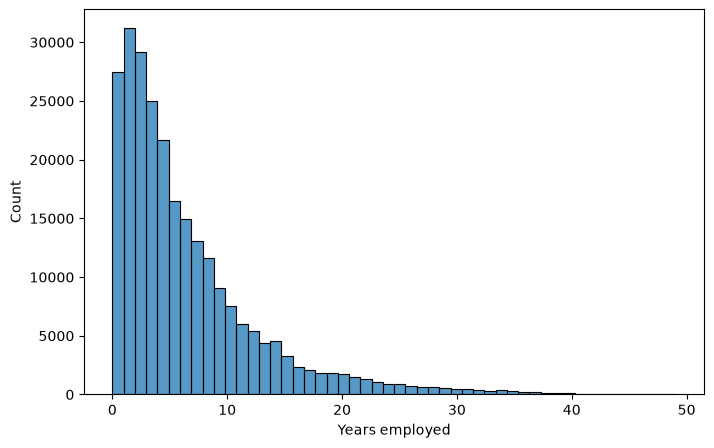

In [81]:
plt.figure(figsize=(8,5))

sns.histplot(
    years_employed,
    bins=50
)

plt.xlabel("Years employed")
plt.show()

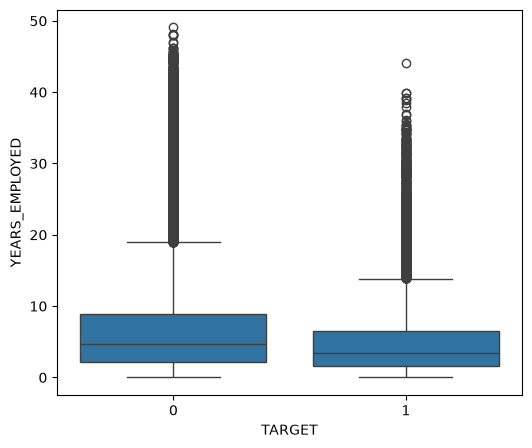

In [82]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_application.assign(YEARS_EMPLOYED=years_employed),
    x="TARGET",
    y="YEARS_EMPLOYED"
)

plt.show()

In [83]:
df_application.assign(
    YEARS_EMPLOYED=years_employed
).groupby("TARGET")["YEARS_EMPLOYED"].agg(
    ["count","mean","median","std"]
)

,count,mean,median,std
TARGET,,,,
0,230302,6.68,4.63,6.50
1,21835,4.97,3.37,5.07


#### Observações

* A quantidade de dias está em valor negativo, o ideal seria transformar em anos com valor positivo na transformação para a ABT.
* Existem vários nulos por conta da sanitização, indicando falta de histórico de emprego. Esses nulos podem carregar poder preditivo, e criação de uma feature de booleana pode ser uma estratégia viável ou imputação com mediana.
* Há uma diferença significativa entre os clientes adimplentes e inadimplentes: Os clientes inadimplentes tendem a ter um histórico de emprego mais curtos.

### 1.4.2 Tipo de Ocupação ```OCCUPATION_TYPE```

In [84]:
occupation_null = df_application["OCCUPATION_TYPE"].isna().sum()
occupation_null_pct = df_application["OCCUPATION_TYPE"].isna().mean()*100

print(f"Quantidade de Nulos: {occupation_null} \nProporção de nulos: {occupation_null_pct}")

Quantidade de Nulos: 96391 
Proporção de nulos: 31.345545362604916


In [85]:
occupation_counts = (
    df_application["OCCUPATION_TYPE"]
    .value_counts()
)
occupation_counts

OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

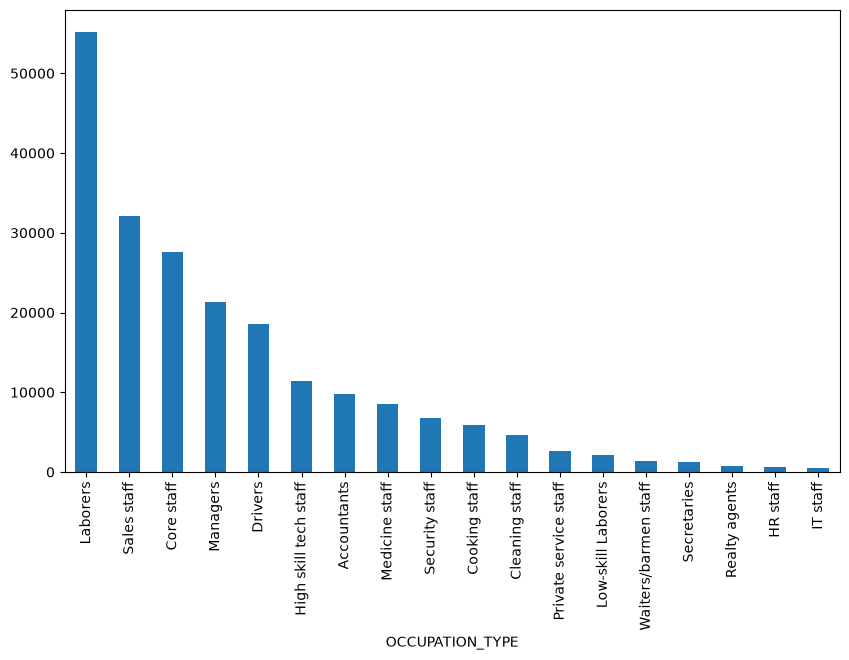

In [86]:
plt.figure(figsize=(10,6))

occupation_counts.plot.bar()

plt.xticks(rotation=90)

plt.show()

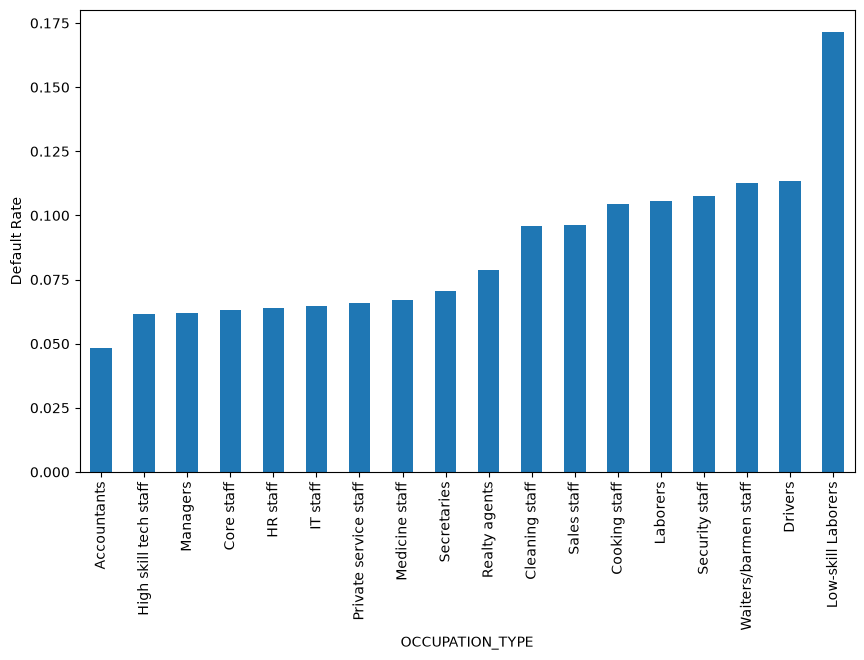

In [87]:
occupation_rate = (
    df_application
    .groupby("OCCUPATION_TYPE", observed=False)["TARGET"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

occupation_rate.plot.bar()

plt.ylabel("Default Rate")

plt.show()

#### Observações

* Grande proporção das observações são nulas (31%). Podemos inserir "Unknown" ou desconhecido para essas observações na criação da ABT. 
* Há diferenças significativas entre a taxa de inadimplencia e a ocupação, sugerindo algum poder preditivo do modelo.

### 1.4.3 Tipo de Organização ```ORGANIZATION_TYPE```

In [88]:
organization_counts = (
    df_application["ORGANIZATION_TYPE"]
    .value_counts()
)

df_application["ORGANIZATION_TYPE"].nunique()

58

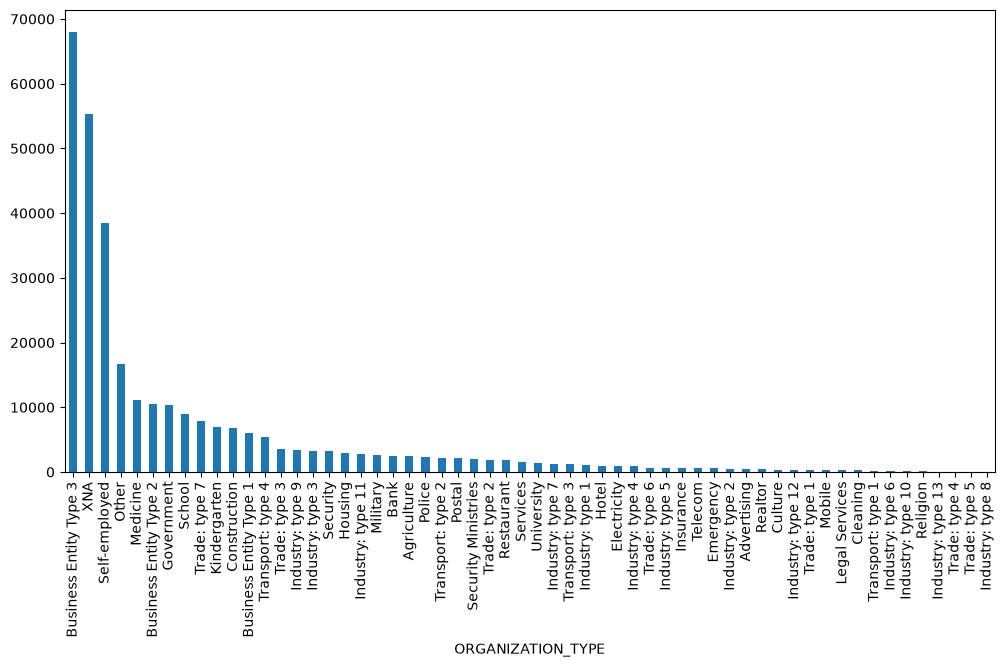

In [89]:
plt.figure(figsize=(12,6))

organization_counts.plot.bar()

plt.xticks(rotation=90)

plt.show()

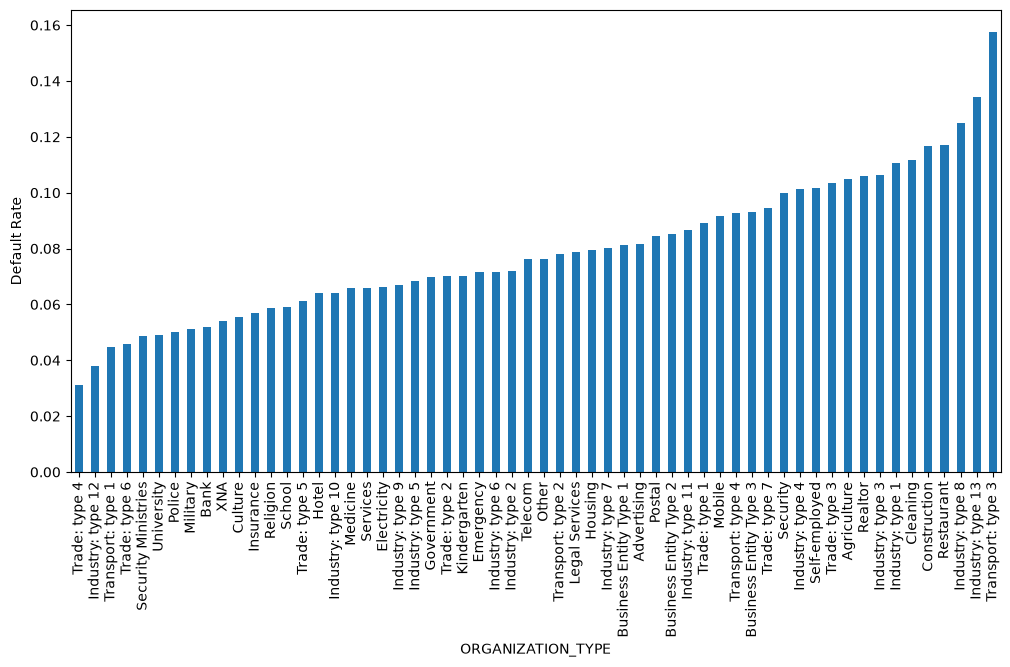

In [90]:
organization_rate = (
    df_application
    .groupby("ORGANIZATION_TYPE", observed=False)["TARGET"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,6))

organization_rate.plot.bar()

plt.ylabel("Default Rate")

plt.xticks(rotation=90)

plt.show()

In [91]:
top_orgs = (
    df_application["ORGANIZATION_TYPE"]
    .value_counts()
    .head(15)
    .index
)

org_rate = (
    df_application[
        df_application["ORGANIZATION_TYPE"].isin(top_orgs)
    ]
    .groupby("ORGANIZATION_TYPE", observed=False)["TARGET"]
    .agg(
        applications="count",
        default_rate="mean"
    )
    .sort_values("applications", ascending=False)
)

org_rate

,applications,default_rate
ORGANIZATION_TYPE,,
Business Entity Type 3,67992,0.09
XNA,55374,0.05
Self-employed,38412,0.10
Other,16683,0.08
Medicine,11193,0.07
Business Entity Type 2,10553,0.09
Government,10404,0.07
School,8893,0.06
Trade: type 7,7831,0.09


#### Observações

* Alta cardinalidade com 58 categorias e distribuição desbalanceada entres os tipos de organização. 
* Pode possuir informação preditiva mas a quantidade de categorias dificulta a interpretação, por isso o ideal seria reduzir a cardinalidade.

### Resumo

1. ```DAYS_EMPLOYED``` pode ser transformado em anos ```YEARS_EMPLOYED```, e contém poder preditivo. 
2. Criar nova feature com as observações nulas do ```YEARS_EMPLOYED```. Imputação com mediana e/ou flag (bool) para indicar desconhecido.
3. ```OCCUPATION_TYPE``` contém vários nulos mas as diferenças entre a taxa de inadimplência entre as categorias indica poder preditivo.
4. ```ORGANIZATION_TYPE``` reduzir cardinalidade de 58 categorias para <20. Agrupar ou usar as 10 mais comuns e agrupar o resto em ```outras```

## 1.5 Variáveis de Habitação

Hipótese: Pessoas com moradias mais estáveis têm menos risco de inadimplência.

In [92]:
habitacao = [
    "FLAG_OWN_REALTY",
    "NAME_HOUSING_TYPE",
]

In [93]:
print("Nulos:")
df_application[habitacao].isna().sum().sort_values(ascending=False)

Nulos:


FLAG_OWN_REALTY      0
NAME_HOUSING_TYPE    0
dtype: int64

### 1.5.1 Possui imóvel? (BOOL) ```FLAG_OWN_REALTY```

In [94]:
(
    df_application["FLAG_OWN_REALTY"]
    .value_counts()
    .to_frame("count")
)

,count
FLAG_OWN_REALTY,
Y,213312
N,94199


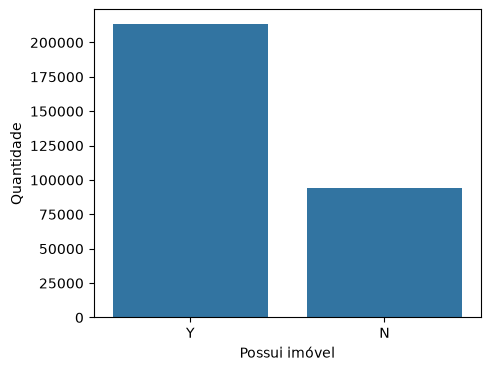

In [95]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=df_application,
    x="FLAG_OWN_REALTY"
)

plt.xlabel("Possui imóvel")
plt.ylabel("Quantidade")

plt.show()

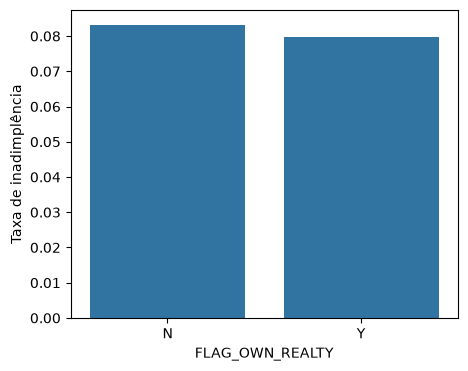

In [96]:
realty_rate = (
    df_application
    .groupby("FLAG_OWN_REALTY")["TARGET"]
    .agg(
        applications="count",
        default_rate="mean"
    )
)

plt.figure(figsize=(5,4))

sns.barplot(
    data=realty_rate.reset_index(),
    x="FLAG_OWN_REALTY",
    y="default_rate"
)

plt.ylabel("Taxa de inadimplência")

plt.show()

#### Observações

* A maioria dos clientes possui imóvel próprio, com uma distribuição relativamente desbalanceada.
* Diferença na taxa de inadimplência entre os grupos é muito pequena, indicando efeito limitado no poder preditivo.

### 1.5.2 Tipo de Habitação ```NAME_HOUSING_TYPE```

In [97]:
df_application["NAME_HOUSING_TYPE"].describe()

count                307511
unique                    6
top       House / apartment
freq                 272868
Name: NAME_HOUSING_TYPE, dtype: object

In [98]:
housing_counts = (
    df_application["NAME_HOUSING_TYPE"]
    .value_counts()
)

housing_counts

NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64

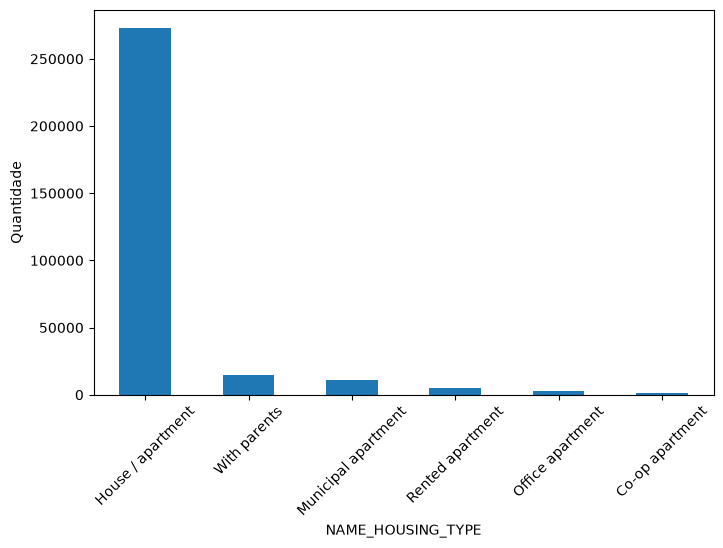

In [99]:
plt.figure(figsize=(8,5))

housing_counts.plot.bar()

plt.xticks(rotation=45)

plt.ylabel("Quantidade")

plt.show()

In [100]:
housing_rate = (
    df_application
    .groupby("NAME_HOUSING_TYPE", observed=False)["TARGET"]
    .agg(
        applications="count",
        default_rate="mean"
    )
    .sort_values("default_rate")
)

housing_rate

,applications,default_rate
NAME_HOUSING_TYPE,,
Office apartment,2617,0.07
House / apartment,272868,0.08
Co-op apartment,1122,0.08
Municipal apartment,11183,0.09
With parents,14840,0.12
Rented apartment,4881,0.12


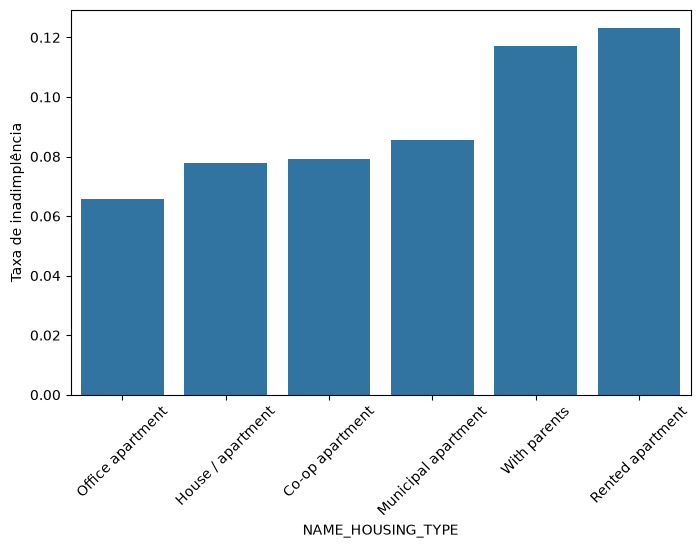

In [101]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=housing_rate.reset_index(),
    x="NAME_HOUSING_TYPE",
    y="default_rate"
)

plt.xticks(rotation=45)

plt.ylabel("Taxa de inadimplência")

plt.show()

#### Observações

* Algumas categorias apresentam taxa de inadimplência elevadas, principalmente apartamento alugado e morando com os pais. 
* A grande maioria da base de clientes moram em casa ou apartamento. A presença de outras categorias de apartamento pode indicar algum erro na coleta dos dados.

### Resumo

1. Não há muita diferença entre a taxa de inadimplência entre pessoas que são proprietários de imóveis. 
2. Algumas categorias em ```NAME_HOUSING_TYPE``` mostram potencial no poder preditivo de inadimplência.

## 1.6 Scores externos

Esses dados representam scores de credito externos. Pode conter poder preditivo alto pois são análises de risco que já foram feitas. Os scores estão entre o intervalo [0,1], com números maiores representando um score elevado e por consequência, risco menor.

In [102]:
scores_externos = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

In [103]:
df_application[scores_externos].head(10)

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,0.08,0.26,0.14
1,0.31,0.62,NaN
2,NaN,0.56,0.73
3,NaN,0.65,NaN
4,NaN,0.32,NaN
5,NaN,0.35,0.62
6,0.77,0.72,0.49
7,NaN,0.71,0.54
8,0.59,0.21,0.75
9,NaN,0.75,NaN


In [104]:
df_application[scores_externos].describe().T

,count,mean,std,min,25%,50%,75%,max
EXT_SOURCE_1,134133.00,0.50,0.21,0.01,0.33,0.51,0.68,0.96
EXT_SOURCE_2,306851.00,0.51,0.19,0.00,0.39,0.57,0.66,0.85
EXT_SOURCE_3,246546.00,0.51,0.19,0.00,0.37,0.54,0.67,0.90


In [105]:
(
    df_application[scores_externos]
    .isna()
    .sum()
    .to_frame("Missing")
    .assign(
        Percent=lambda x: 100 * x["Missing"] / len(df_application)
    )
)

,Missing,Percent
EXT_SOURCE_1,173378,56.38
EXT_SOURCE_2,660,0.21
EXT_SOURCE_3,60965,19.83


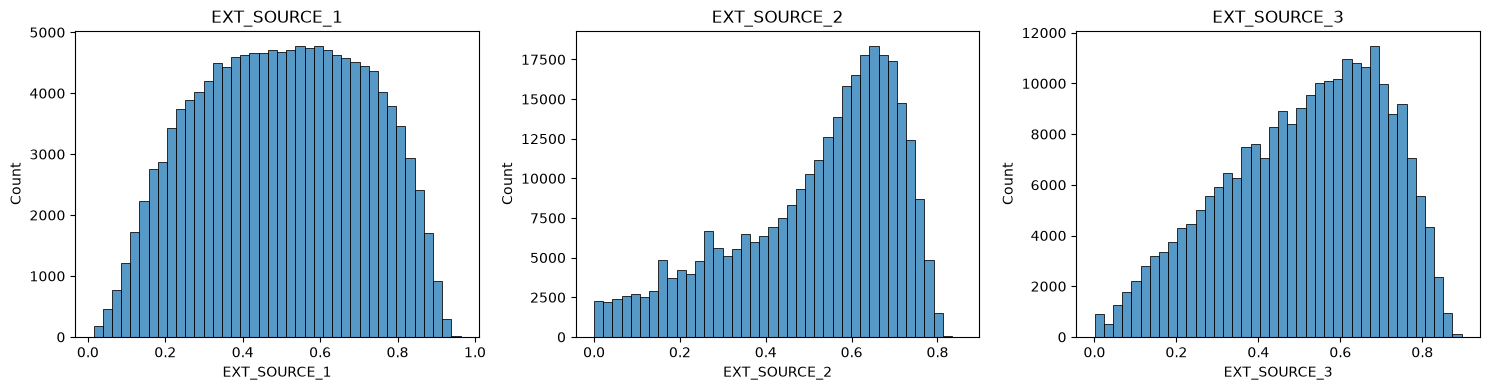

In [106]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, col in zip(axes, scores_externos):

    sns.histplot(
        df_application[col],
        bins=40,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()

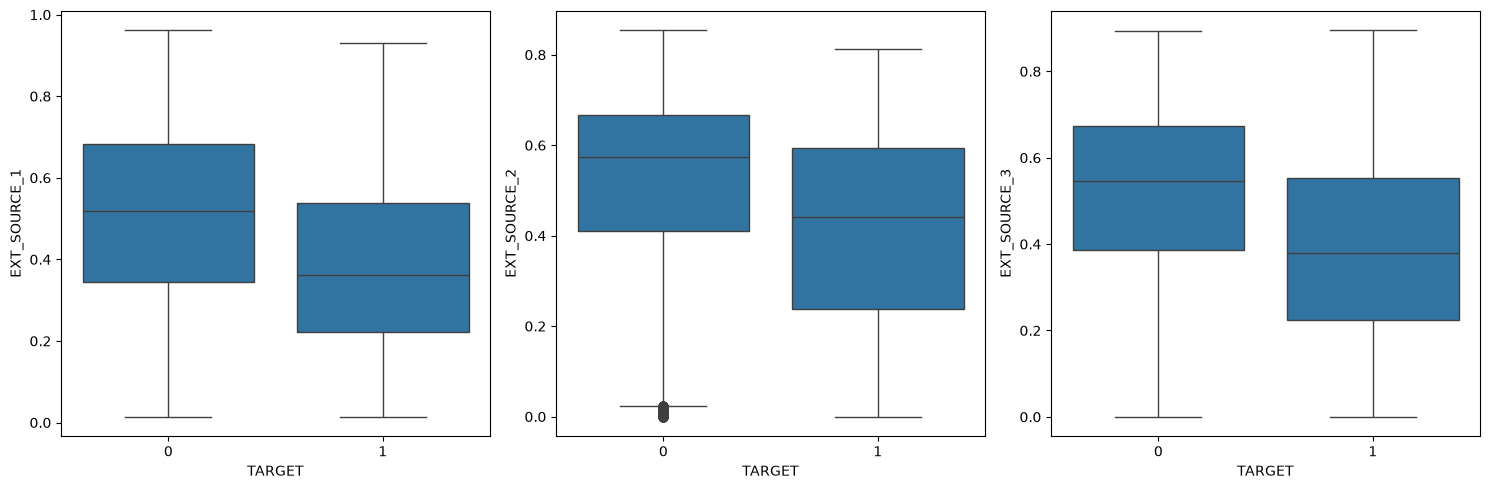

In [107]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

for ax, col in zip(axes, scores_externos):

    sns.boxplot(
        data=df_application,
        x="TARGET",
        y=col,
        ax=ax
    )

plt.tight_layout()

In [108]:
for col in scores_externos:

    print(col)

    display(
        df_application.groupby("TARGET")[col].agg(
            ["count","mean","median","std"]
        )
    )

EXT_SOURCE_1


,count,mean,median,std
TARGET,,,,
0,124079,0.51,0.52,0.21
1,10054,0.39,0.36,0.20


EXT_SOURCE_2


,count,mean,median,std
TARGET,,,,
0,282078,0.52,0.57,0.19
1,24773,0.41,0.44,0.21


EXT_SOURCE_3


,count,mean,median,std
TARGET,,,,
0,227398,0.52,0.55,0.19
1,19148,0.39,0.38,0.21


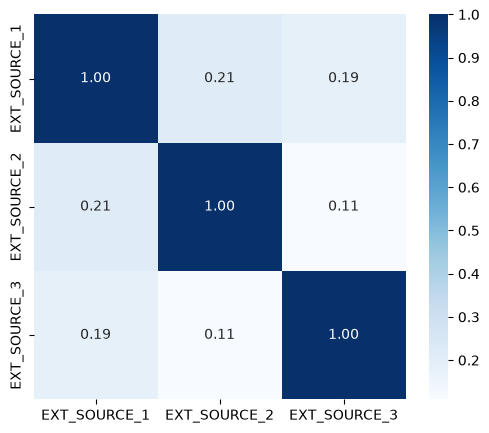

In [109]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df_application[scores_externos].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.show()

### Observações

* As 3 variáveis apresentam distribuições diferentes e contêm diferentes proporções de valores ausentes, indicando fontes externas independentes.
* Para cada fonte externa, clientes inadimplentes representam scores inferiores aos clientes adimplentes, sugerindo um forte poder preditivo de risco.
* Os 3 scores apresentam correlação positiva entre si, sugerindo que são informações complementares.

## Resumo Geral ```application_train```

* A variável `TARGET` apresenta forte desbalanceamento, com aproximadamente 92% dos clientes adimplentes e 8% inadimplentes, aspecto que deverá ser considerado durante a modelagem.
* Entre as variáveis demográficas, idade, estado civil, escolaridade, número de filhos e tipo de renda mostram diferenças entre clientes adimplentes e inadimplentes, sugerindo potencial poder preditivo.
* As variáveis financeiras (`AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY` e `AMT_GOODS_PRICE`) possuem distribuições bastante assimétricas e presença de outliers, indicando que medidas robustas e possíveis transformações poderão ser úteis na etapa de modelagem.
* As variáveis financeiras isoladas apresentam apenas separação moderada entre as classes, mas as relações entre elas parecem capturar melhor o comprometimento financeiro do cliente.
* O feature engineering de indicadores como Credit-to-Income Ratio, Annuity-to-Income Ratio e Credit-to-Goods Ratio mostra que a combinação de variáveis pode gerar atributos mais informativos do que seus valores absolutos.

# 2. Analisando a base suplementar ```bureau```

Esta base contém os dados de créditos prévios de outras institutições financeiras que foram reportadas ao Crredit Bureau. O foco de usar esta base será mais para dar apoio à base principal, por meio de agregações.

In [110]:
resumo_inicial(df_bureau, "bureau")

RESUMO INICIAL - BUREAU

Dimensões: 1,716,428 linhas × 17 colunas

--------------------------------------------------------------------------------
Informações das colunas
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int32  
 1   SK_ID_BUREAU            int32  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             float32
 5   CREDIT_DAY_OVERDUE      int16  
 6   DAYS_CREDIT_ENDDATE     float32
 7   DAYS_ENDDATE_FACT       float32
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      float32
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SK_ID_CURR,1716428.00,NaN,NaN,NaN,278214.93,102938.56,100001.00,188866.75,278055.00,367426.00,456255.00
SK_ID_BUREAU,1716428.00,NaN,NaN,NaN,5924434.49,532265.73,5000000.00,5463953.75,5926303.50,6385681.25,6843457.00
CREDIT_ACTIVE,1716428,4,Closed,1079273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CREDIT_CURRENCY,1716428,4,currency 1,1715020,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DAYS_CREDIT,1716428.00,NaN,NaN,NaN,-1142.11,795.16,-2922.00,-1666.00,-987.00,-474.00,0.00
CREDIT_DAY_OVERDUE,1716428.00,NaN,NaN,NaN,0.82,36.54,0.00,0.00,0.00,0.00,2792.00
DAYS_CREDIT_ENDDATE,1610875.00,NaN,NaN,NaN,510.52,4994.22,-42060.00,-1138.00,-330.00,474.00,31199.00
DAYS_ENDDATE_FACT,1082775.00,NaN,NaN,NaN,-1017.44,714.01,-42023.00,-1489.00,-897.00,-425.00,0.00
AMT_CREDIT_MAX_OVERDUE,591940.00,NaN,NaN,NaN,3825.42,206031.61,0.00,0.00,0.00,0.00,115987185.00
CNT_CREDIT_PROLONG,1716428.00,NaN,NaN,NaN,0.01,0.10,0.00,0.00,0.00,0.00,9.00


Cada linha representa um empréstimo anterior registrado em uma outra instituição de crédito.

### 2.1 Checagem de Nulos

In [111]:
df_bureau.isna().sum().sort_values(ascending=False)

AMT_ANNUITY               1226791
AMT_CREDIT_MAX_OVERDUE    1124488
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_SUM_LIMIT       592131
AMT_CREDIT_SUM_DEBT        266087
DAYS_CREDIT_ENDDATE        105553
DAYS_CREDIT_UPDATE             17
AMT_CREDIT_SUM                 13
CREDIT_ACTIVE                   0
CREDIT_CURRENCY                 0
DAYS_CREDIT                     0
CREDIT_DAY_OVERDUE              0
SK_ID_BUREAU                    0
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM_OVERDUE          0
CREDIT_TYPE                     0
SK_ID_CURR                      0
dtype: int64

### 2.2 Registros por Cliente

In [112]:
creditos_cliente = (
    df_bureau
    .groupby("SK_ID_CURR")
    .size()
)

creditos_cliente.describe()

count   305811.00
mean         5.61
std          4.43
min          1.00
25%          2.00
50%          4.00
75%          8.00
max        116.00
dtype: float64

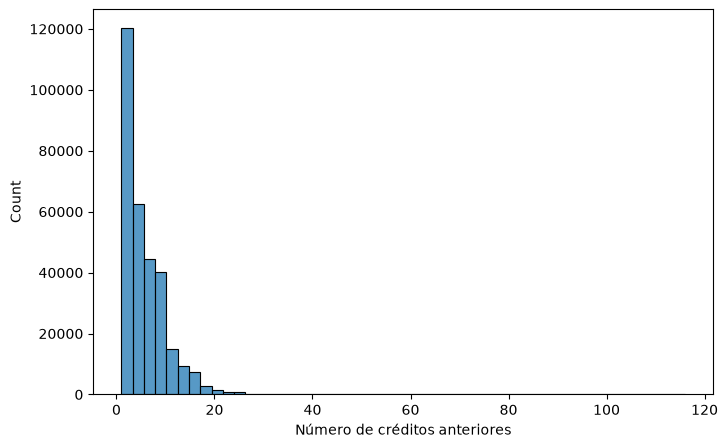

In [113]:
plt.figure(figsize=(8,5))

sns.histplot(
    creditos_cliente,
    bins=50
)

plt.xlabel("Número de créditos anteriores")

plt.show()

#### Observações

* Maioria dos clientes possuem poucos registros, entre 1 e 8 créditos anteriores.
* Alguns clientes possuem dezenas de empréstimos.
* Pode ser feita uma agregação contando a quantidade de empréstimos.

### 2.3 Variáveis Categóricas

In [114]:
bureau_categorias = [
    "CREDIT_ACTIVE",
    "CREDIT_TYPE",
    "CREDIT_CURRENCY"
]

#### 2.3.1 Créditos Ativos ```CREDIT_ACTIVE```

In [115]:
df_bureau["CREDIT_ACTIVE"].value_counts()

CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='CREDIT_ACTIVE'>

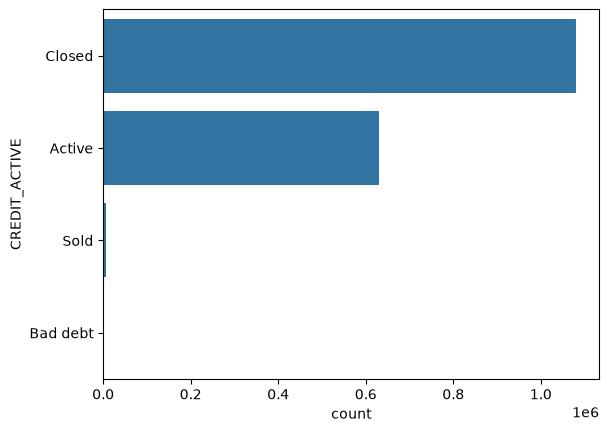

In [116]:
sns.countplot(
    data=df_bureau,
    y="CREDIT_ACTIVE",
    order=df_bureau["CREDIT_ACTIVE"].value_counts().index
)

##### Observações

* 630k créditos ativos e ~1.08M encerrados.
* Possibilidade de novas features contando a quantidade de créditos ativos, créditos encerrados, e proporção dos dois.

#### 2.3.2 Tipo de Crédito ```CREDIT_TYPE```

In [117]:
df_bureau["CREDIT_TYPE"].value_counts()

CREDIT_TYPE
Consumer credit                                 1251615
Credit card                                      402195
Car loan                                          27690
Mortgage                                          18391
Microloan                                         12413
Loan for business development                      1975
Another type of loan                               1017
Unknown type of loan                                555
Loan for working capital replenishment              469
Cash loan (non-earmarked)                            56
Real estate loan                                     27
Loan for the purchase of equipment                   19
Loan for purchase of shares (margin lending)          4
Mobile operator loan                                  1
Interbank credit                                      1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='CREDIT_TYPE'>

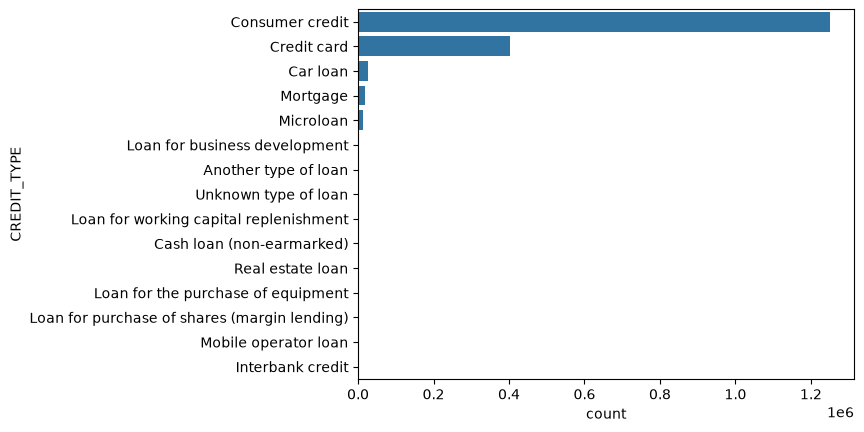

In [118]:
sns.countplot(
    data=df_bureau,
    y="CREDIT_TYPE",
    order=df_bureau["CREDIT_TYPE"].value_counts().index
)

##### Observações

* Duas categorias são predominantes; ```consumer credit``` e ```credit card```. 
* Três categorias também se destacam um pouco: ```car loan```, ```mortgage```, e ```microloan```.
* Possibilidade de fazer feature engineering com as top 5 ou top 7 individuais e agregar o resto como outros.

#### 2.3.3 Moeda ```CREDIT_CURRENCY```

In [119]:
df_bureau["CREDIT_CURRENCY"].value_counts()

CREDIT_CURRENCY
currency 1    1715020
currency 2       1224
currency 3        174
currency 4         10
Name: count, dtype: int64

##### Observações

* Praticamente uma categoria de 1 moeda utilizada. As outras poderiam ser agrupadas.

### 2.4 Variáveis Temporais

In [120]:
bureau_temporais = [
    "DAYS_CREDIT",
    "DAYS_CREDIT_ENDDATE",
    "DAYS_ENDDATE_FACT"
]

In [121]:
df_bureau[bureau_temporais].isna().sum().sort_values(ascending=False)

DAYS_ENDDATE_FACT      633653
DAYS_CREDIT_ENDDATE    105553
DAYS_CREDIT                 0
dtype: int64

#### 2.4.1 ```DAYS_CREDIT```

Dias desde que o crédito foi concedido.

<Axes: xlabel='DAYS_CREDIT', ylabel='Count'>

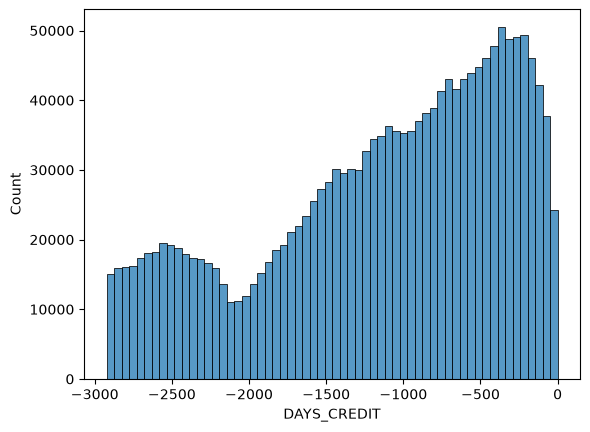

In [122]:
sns.histplot(
    df_bureau["DAYS_CREDIT"],
    bins=60
)

In [123]:
df_bureau["DAYS_CREDIT"].describe()

count   1716428.00
mean      -1142.11
std         795.16
min       -2922.00
25%       -1666.00
50%        -987.00
75%        -474.00
max           0.00
Name: DAYS_CREDIT, dtype: float64

##### Observações

* Valores são negativos, então tratar para positivo na ABT.
* Grande parte dos valores são mais recentes, mas há um histórico antigo notável entre 2000 e 3000 dias.

#### 2.4.2 ```DAYS_CREDIT_ENDDATE```

Dias restantes do crédito no Credit Bureau quando solicitou o empréstimo de Home Credit.

In [124]:
df_bureau["DAYS_CREDIT_ENDDATE"].isna().sum()

105553

In [125]:
df_bureau["DAYS_CREDIT_ENDDATE"].describe()

count   1610875.00
mean        510.52
std        4994.22
min      -42060.00
25%       -1138.00
50%        -330.00
75%         474.00
max       31199.00
Name: DAYS_CREDIT_ENDDATE, dtype: float64

<Axes: xlabel='DAYS_CREDIT_ENDDATE', ylabel='Count'>

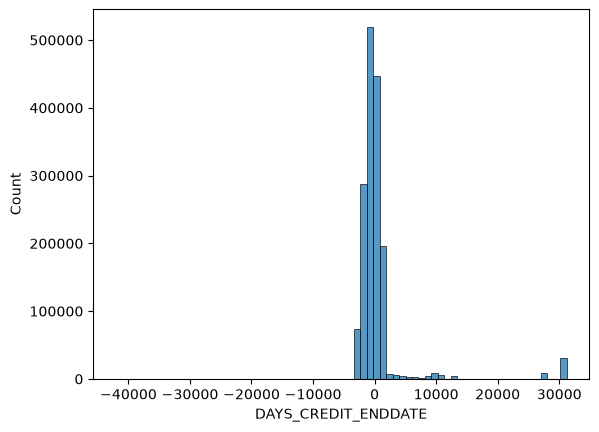

In [126]:
sns.histplot(
    df_bureau["DAYS_CREDIT_ENDDATE"].dropna(),
    bins=70
)

##### Observações

* Os valores desta variável contém negativos e positivos, para indicar se a data prevista do término já havia passado na data da solicitação do empréstimo ou se o crédito está para vencer no futuro.
* A mediana negativa de -330 dias indica que mais da metade dos registros já estão expirados em relação à data prevista.
* Os valores extremos -42060 e 31199 indicam créditos expirados há anos e créditos com expiração de longo prazo.
* Possibilidade de feature engineering com proporção de créditos ativos em relação ao total ou número de créditos ainda em andamento.

#### 2.4.3 ```DAYS_ENDDATE_FACT```

Número de dias desde a solicitação de empréstimo em que o crédito foi efetivamente encerrado

In [127]:
df_bureau["DAYS_ENDDATE_FACT"].describe()

count   1082775.00
mean      -1017.44
std         714.01
min      -42023.00
25%       -1489.00
50%        -897.00
75%        -425.00
max           0.00
Name: DAYS_ENDDATE_FACT, dtype: float64

In [128]:
missing = df_bureau["DAYS_ENDDATE_FACT"].isna().mean() * 100
print(f"Missing: {missing:.2f}%")

Missing: 36.92%


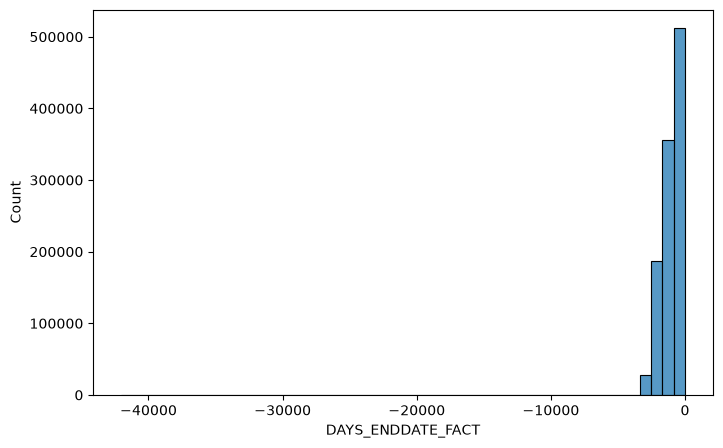

In [129]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_bureau["DAYS_ENDDATE_FACT"].dropna(),
    bins=50
)

plt.show()

##### Observações

* Vários nulos, provavelmente correspondendo a créditos ainda ativos. 
* Distribuição assimétrica, com concetração de créditos encerrados mais recentementes, com alguns registros de créditos finalizados há muitos anos.

### 2.5 Variáveis Monetárias

In [130]:
bureau_monetarias = [
    "AMT_CREDIT_SUM",
    "AMT_CREDIT_SUM_DEBT",
    "AMT_CREDIT_SUM_OVERDUE",
    "AMT_ANNUITY",
]

In [131]:
df_bureau[bureau_monetarias].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_CREDIT_SUM,1716415.00,354994.59,1149811.34,0.00,51300.00,125518.50,315000.00,585000000.00
AMT_CREDIT_SUM_DEBT,1450341.00,137926.12,679233.83,0.00,0.00,0.00,41400.00,170100000.00
AMT_CREDIT_SUM_OVERDUE,1716428.00,37.91,5937.65,0.00,0.00,0.00,0.00,3756681.00
AMT_ANNUITY,489637.00,15712.76,325826.95,0.00,0.00,0.00,13500.00,118453423.50


In [132]:
(
    df_bureau[bureau_monetarias]
    .isna()
    .sum()
    .to_frame("Missing")
    .assign(
        Percent=lambda x: 100 * x["Missing"] / len(df_bureau)
    )
)

,Missing,Percent
AMT_CREDIT_SUM,13,0.00
AMT_CREDIT_SUM_DEBT,266087,15.50
AMT_CREDIT_SUM_OVERDUE,0,0.00
AMT_ANNUITY,1226791,71.47


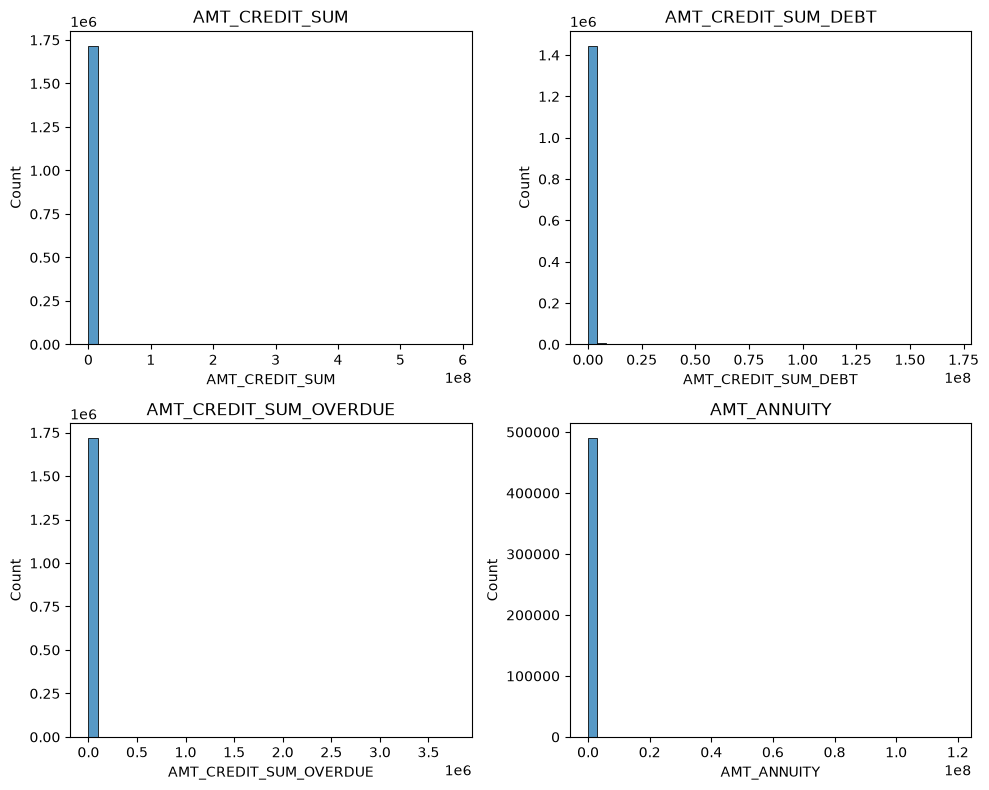

In [133]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, col in zip(axes.flat, bureau_monetarias):
    sns.histplot(df_bureau[col], bins=40, ax=ax)
    ax.set_title(col)

plt.tight_layout()

In [134]:
(
    (df_bureau["AMT_CREDIT_SUM_OVERDUE"] == 0)
    .mean()
)

0.9975775272834049

#### Observações

* ```AMT_CREDIT_SUM``` representa o valor total do crédito registrado no bureau e apresenta elevada variabilidade, com forte assimetria à direita e contratos de valores muito elevados.
* ```AMT_CREDIT_SUM_DEBT``` possui mediana igual a zero, indicando que mais da metade dos registros não possui dívida pendente no momento da consulta.
* ```AMT_CREDIT_SUM_OVERDUE``` é altamente concentrada em zero, sugerindo que apenas uma pequena parcela dos créditos apresenta valores em atraso. 
* ```AMT_ANNUITY``` apresenta grande quantidade de valores iguais a zero e grande proporção de valores ausentes, indicando que essa informação está disponível apenas para parte dos contratos.
* Essas variáveis serão mais úteis quando agregadas e cruzadas com ```SK_ID_CURR``` na ABT.

### Resumo da base ```bureau```

1. O principal objetivo desta base é para gerar valor por meio de agregações e cruzamentos de dados com a base principal `application_train`.
2. A maioria dos clientes possui poucos registros de crédito, enquanto uma pequena parcela apresenta um histórico de empréstimos significativamente maior.
3. As variáveis categóricas (`CREDIT_ACTIVE` e `CREDIT_TYPE`) fornecem informações importantes sobre o perfil e o estado dos empréstimos anteriores e podem ser resumidas por meio de contagens e proporções.
4. As variáveis temporais (```DAYS_CREDIT```, `DAYS_CREDIT_ENDDATE` e DAYS_ENDDATE_FACT) capturam a recência e a duração do histórico de crédito e podem ser transformadas em indicadores como crédito mais recente, mais antigo e tempo médio desde a contratação.
5. As variáveis monetárias (`AMT_CREDIT_SUM`, `AMT_CREDIT_SUM_DEBT`, `AMT_CREDIT_SUM_OVERDUE`) permitem caracterizar o endividamento histórico dos clientes através de estatísticas agregadas.


<Axes: >

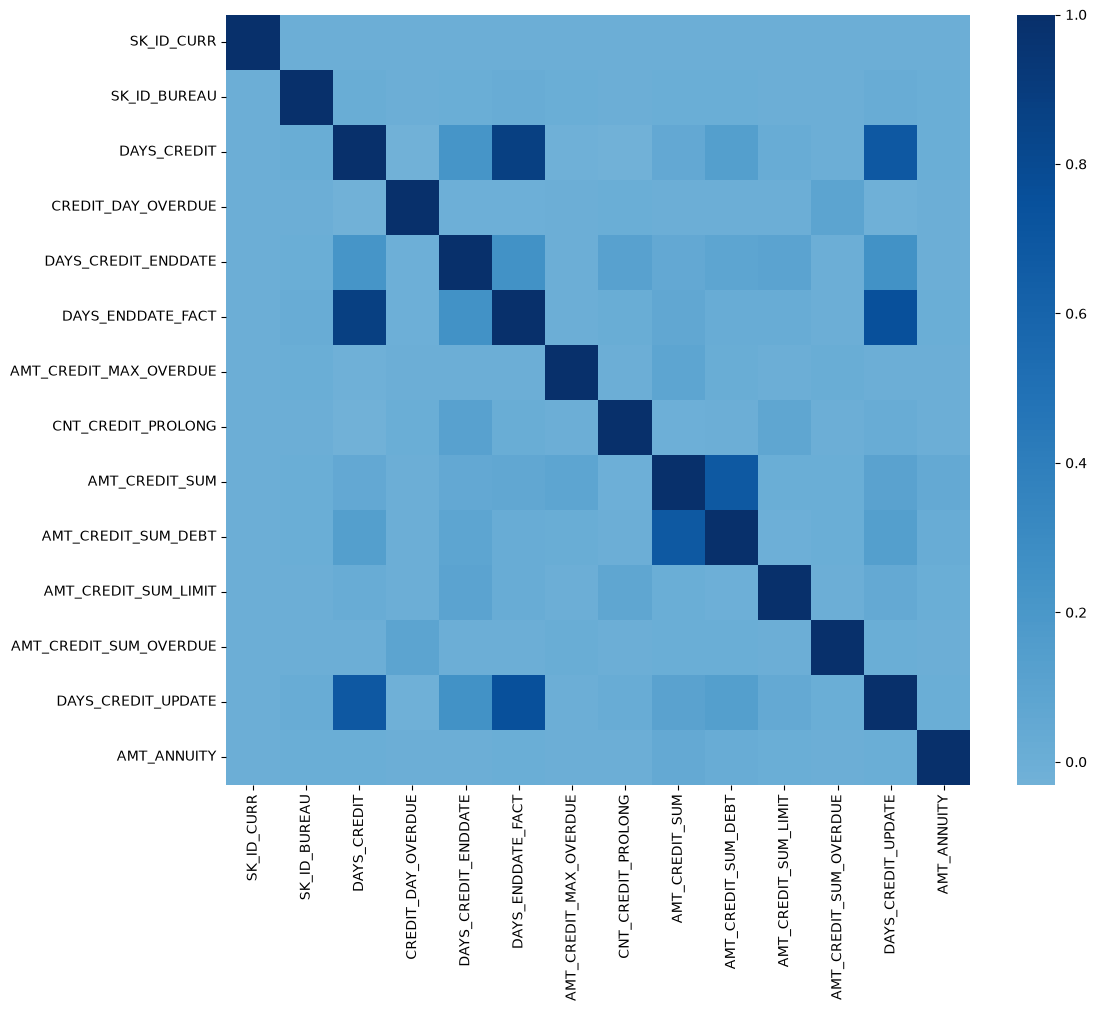

In [135]:
numeric = df_bureau.select_dtypes(include="number")

plt.figure(figsize=(12,10))

sns.heatmap(
    numeric.corr(),
    cmap="Blues",
    center=0
)

In [136]:
df_bureau["CREDIT_ACTIVE"].value_counts(normalize=True)

pd.crosstab(
    df_bureau["CREDIT_ACTIVE"],
    df_bureau["CREDIT_TYPE"]
)

CREDIT_TYPE,Another type of loan,Car loan,Cash loan (non-earmarked),Consumer credit,Credit card,Interbank credit,Loan for business development,Loan for purchase of shares (margin lending),Loan for the purchase of equipment,Loan for working capital replenishment,Microloan,Mobile operator loan,Mortgage,Real estate loan,Unknown type of loan
CREDIT_ACTIVE,,,,,,,,,,,,,,,
Active,202,9926,42,317829,285998,0,351,2,5,223,3025,1,12871,16,116
Bad debt,0,0,0,16,5,0,0,0,0,0,0,0,0,0,0
Closed,801,17277,6,930574,114057,1,1619,2,14,229,9347,0,4898,9,439
Sold,14,487,8,3196,2135,0,5,0,0,17,41,0,622,2,0


# 3. Analisando a base suplementar ```previous_application```

Esta base contém o histórico de solicitações anteriores do cliente à própria Home Credit. O objetivo é continuar a fazer agregações por `SK_ID_CURR` para servir na ABT.

In [137]:
resumo_inicial(df_previous_application)

RESUMO INICIAL - DATAFRAME

Dimensões: 1,670,214 linhas × 37 colunas

--------------------------------------------------------------------------------
Informações das colunas
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int32  
 1   SK_ID_CURR                   1670214 non-null  int32  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774368 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SK_ID_PREV,1670214.00,NaN,NaN,NaN,1923089.14,532597.96,1000001.00,1461857.25,1923110.50,2384279.75,2845382.00
SK_ID_CURR,1670214.00,NaN,NaN,NaN,278357.17,102814.82,100001.00,189329.00,278714.50,367514.00,456255.00
NAME_CONTRACT_TYPE,1670214,4,Cash loans,747553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMT_ANNUITY,1297979.00,NaN,NaN,NaN,15955.12,14782.14,0.00,6321.78,11250.00,20658.42,418058.15
AMT_APPLICATION,1670214.00,NaN,NaN,NaN,175233.86,292779.76,0.00,18720.00,71046.00,180360.00,6905160.00
AMT_CREDIT,1670213.00,NaN,NaN,NaN,196114.02,318574.62,0.00,24160.50,80541.00,216418.50,6905160.00
AMT_DOWN_PAYMENT,774368.00,NaN,NaN,NaN,6697.42,20921.52,0.00,0.00,1638.00,7740.00,3060045.00
AMT_GOODS_PRICE,1284699.00,NaN,NaN,NaN,227847.28,315396.56,0.00,50841.00,112320.00,234000.00,6905160.00
WEEKDAY_APPR_PROCESS_START,1670214,7,TUESDAY,255118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HOUR_APPR_PROCESS_START,1670214.00,NaN,NaN,NaN,12.48,3.33,0.00,10.00,12.00,15.00,23.00


In [138]:
df_previous_application.head(10)

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.43,17145.00,17145.00,0.00,17145.00,SATURDAY,15,...,Connectivity,12.00,middle,POS mobile with interest,NaN,-42.00,300.00,-42.00,-37.00,0.00
1,2802425,108129,Cash loans,25188.62,607500.00,679671.00,NaN,607500.00,THURSDAY,11,...,XNA,36.00,low_action,Cash X-Sell: low,NaN,-134.00,916.00,NaN,NaN,1.00
2,2523466,122040,Cash loans,15060.74,112500.00,136444.50,NaN,112500.00,TUESDAY,11,...,XNA,12.00,high,Cash X-Sell: high,NaN,-271.00,59.00,NaN,NaN,1.00
3,2819243,176158,Cash loans,47041.33,450000.00,470790.00,NaN,450000.00,MONDAY,7,...,XNA,12.00,middle,Cash X-Sell: middle,NaN,-482.00,-152.00,-182.00,-177.00,1.00
4,1784265,202054,Cash loans,31924.40,337500.00,404055.00,NaN,337500.00,THURSDAY,9,...,XNA,24.00,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN
5,1383531,199383,Cash loans,23703.93,315000.00,340573.50,NaN,315000.00,SATURDAY,8,...,XNA,18.00,low_normal,Cash X-Sell: low,NaN,-654.00,-144.00,-144.00,-137.00,1.00
6,2315218,175704,Cash loans,NaN,0.00,0.00,NaN,NaN,TUESDAY,11,...,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN
7,1656711,296299,Cash loans,NaN,0.00,0.00,NaN,NaN,MONDAY,7,...,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN
8,2367563,342292,Cash loans,NaN,0.00,0.00,NaN,NaN,MONDAY,15,...,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN
9,2579447,334349,Cash loans,NaN,0.00,0.00,NaN,NaN,SATURDAY,15,...,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN


### 3.1 Quantidade de solicitações anteriores

In [139]:
applications_per_client = (
    df_previous_application
    .groupby("SK_ID_CURR")
    .size()
)

applications_per_client.describe()

count   338857.00
mean         4.93
std          4.22
min          1.00
25%          2.00
50%          4.00
75%          7.00
max         77.00
dtype: float64

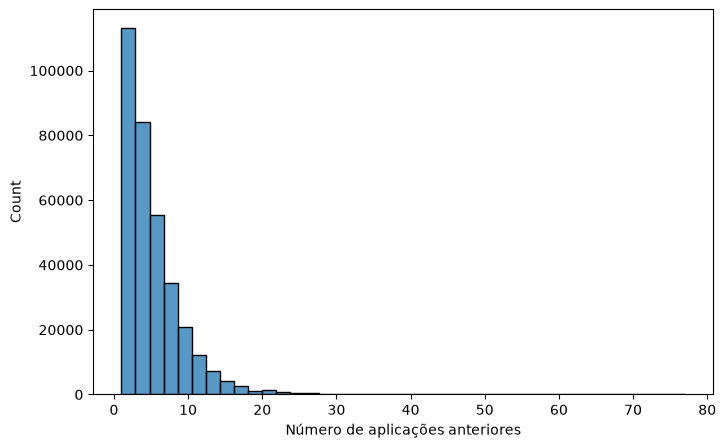

In [140]:
plt.figure(figsize=(8,5))

sns.histplot(
    applications_per_client,
    bins=40
)

plt.xlabel("Número de aplicações anteriores")

plt.show()

#### Observações

* A maioria dos clientes possui poucas solicitações anteriores, com a média e mediana por volta de 5 aplicações anterioes.
* Feature engineering: Contagem de solicitações anteriores com uma nova feature `PREV_APPLICATION_COUNT`

### 3.2 Valores Nulos

In [141]:
(
    df_previous_application
    .isna()
    .mean()
    .sort_values(ascending=False)
)

RATE_INTEREST_PRIVILEGED      1.00
RATE_INTEREST_PRIMARY         1.00
DAYS_FIRST_DRAWING            0.96
DAYS_TERMINATION              0.54
AMT_DOWN_PAYMENT              0.54
RATE_DOWN_PAYMENT             0.54
DAYS_LAST_DUE                 0.53
NAME_TYPE_SUITE               0.49
DAYS_LAST_DUE_1ST_VERSION     0.46
DAYS_FIRST_DUE                0.43
NFLAG_INSURED_ON_APPROVAL     0.40
AMT_GOODS_PRICE               0.23
AMT_ANNUITY                   0.22
CNT_PAYMENT                   0.22
PRODUCT_COMBINATION           0.00
AMT_CREDIT                    0.00
NAME_YIELD_GROUP              0.00
NAME_PORTFOLIO                0.00
NAME_SELLER_INDUSTRY          0.00
SELLERPLACE_AREA              0.00
CHANNEL_TYPE                  0.00
NAME_PRODUCT_TYPE             0.00
SK_ID_PREV                    0.00
NAME_GOODS_CATEGORY           0.00
NAME_CLIENT_TYPE              0.00
CODE_REJECT_REASON            0.00
SK_ID_CURR                    0.00
DAYS_DECISION                 0.00
NAME_CONTRACT_STATUS

In [142]:
(
    df_previous_application
    .groupby("NAME_CONTRACT_STATUS")[
        "DAYS_TERMINATION"
    ]
    .apply(lambda x: x.notna().mean())
)

NAME_CONTRACT_STATUS
Approved       0.74
Canceled       0.00
Refused        0.00
Unused offer   0.00
Name: DAYS_TERMINATION, dtype: float64

Observações

* Algumas variáveis têm índices muito altos de nulos. As três com mais nulos podem ser removidas na transformação para a ABT (`RATE_INTEREST_PRIMARY`, `RATE_INTEREST_PRIVILEGED`, `DAYS_FIRST_DRAWING`)
* Outras variáveis `RATE_INTEREST_PRIMARY`, `RATE_INTEREST_PRIVILEGED`, `DAYS_FIRST_DRAWING` mostram índice alto de nulo porque não foram registradas para a grande maioria dos contratos. Essas também podem ser dropadas.
* Outra váriaveis com nulos podem ser tratados por imputação dependendo da estratégia.

### 3.3 Status do Contrato `NAME_CONTRACT_STATUS`

Informa o resultado de cada solicitação de crédito anterior, respondendo se o cliente já teve empréstimos aprovados, cancelados, recusados.

Cria um histórico para o cliente e isso auxilia na informação do cliente.

In [143]:
df_previous_application["NAME_CONTRACT_STATUS"].value_counts()

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64

In [144]:
(
    df_previous_application["NAME_CONTRACT_STATUS"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

NAME_CONTRACT_STATUS
Approved       62.07
Canceled       18.94
Refused        17.40
Unused offer    1.58
Name: proportion, dtype: float64

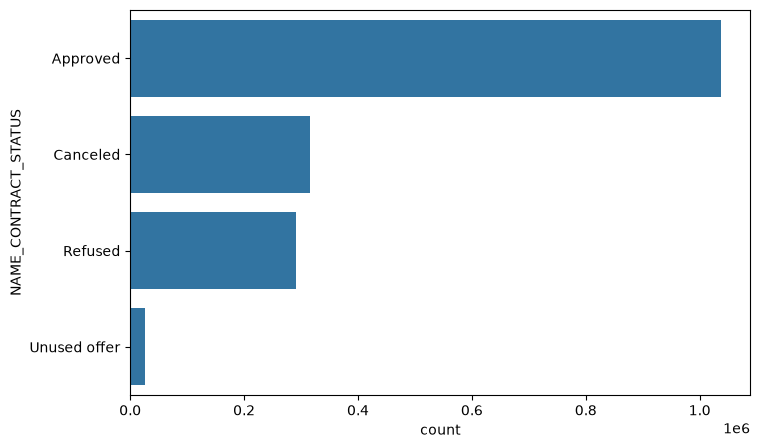

In [145]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_previous_application,
    y="NAME_CONTRACT_STATUS",
    order=df_previous_application["NAME_CONTRACT_STATUS"].value_counts().index
)

plt.show()

#### Observações

* A maioria das solicitações anteriores foi aprovada (62.07%), seguida por uma parcela menor de solicitações recusadas e canceladas.
* O histórico de decisões de crédito pode refletir o perfil de risco e o relacionamento prévio do cliente com a instituição.
* Como um mesmo cliente pode possuir múltiplas solicitações anteriores, `NAME_CONTRACT_STATUS` deve ser agregada por `SK_ID_CURR` para compor a ABT.
* Feature engineering: Novas features de métricas como número de solicitações aprovadas, canceladas, e recusadas, e proporções das mesmas.

### 3.4 `NAME_CONTRACT_TYPE` 

O tipo de crédito que o cliente solicitou

In [146]:
contract_type = (
    df_previous_application["NAME_CONTRACT_TYPE"]
    .value_counts()
    .to_frame("count")
)

contract_type

,count
NAME_CONTRACT_TYPE,
Cash loans,747553
Consumer loans,729151
Revolving loans,193164
XNA,346


In [147]:
(
    df_previous_application["NAME_CONTRACT_TYPE"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

NAME_CONTRACT_TYPE
Cash loans        44.76
Consumer loans    43.66
Revolving loans   11.57
XNA                0.02
Name: proportion, dtype: float64

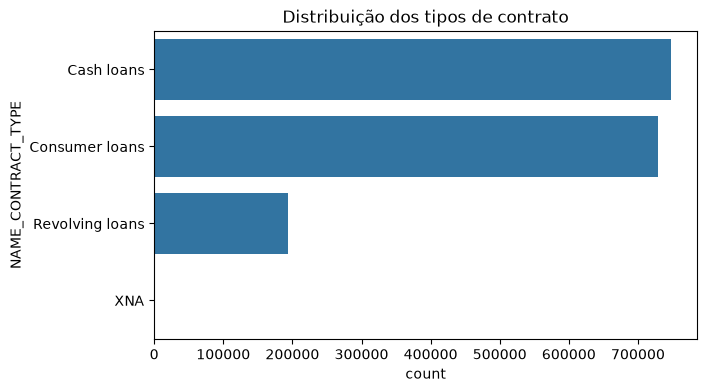

In [148]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df_previous_application,
    y="NAME_CONTRACT_TYPE",
    order=df_previous_application["NAME_CONTRACT_TYPE"].value_counts().index
)

plt.title("Distribuição dos tipos de contrato")

plt.show()

#### Observações

* Cash loans e consumer loans representam quase ~90% das aplicações anteriores. Revolving loans representam uma parcela menor, mas que combinados, representam quase toda a base.
* Essa variável parece ser mais para caracterizar o perfil histórico de crédito de cliente, mas focado na modalidade de crédito. Descreve o tipo de empréstimo e por isso talvez tenha menor poder preditivo depois de cruzamentos e agregações.
* Portanto, poderá ser usada para feature engineering em criar contagems.

### 3.5 `AMT_APPLICATION` e `AMT_CREDIT`

Valores monetários de quanto o cliente pediu e quanto foi concedido

In [149]:
df_previous_application[["AMT_APPLICATION", "AMT_CREDIT"]].describe()

,AMT_APPLICATION,AMT_CREDIT
count,1670214.00,1670213.00
mean,175233.86,196114.02
std,292779.76,318574.62
min,0.00,0.00
25%,18720.00,24160.50
50%,71046.00,80541.00
75%,180360.00,216418.50
max,6905160.00,6905160.00


In [150]:
df_previous_application[
    ["AMT_APPLICATION", "AMT_CREDIT"]
].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
AMT_APPLICATION,1670214.00,175233.86,292779.76,0.00,0.00,0.00,18720.00,71046.00,180360.00,787500.00,1350000.00,6905160.00
AMT_CREDIT,1670213.00,196114.02,318574.62,0.00,0.00,0.00,24160.50,80541.00,216418.50,886500.00,1515377.70,6905160.00


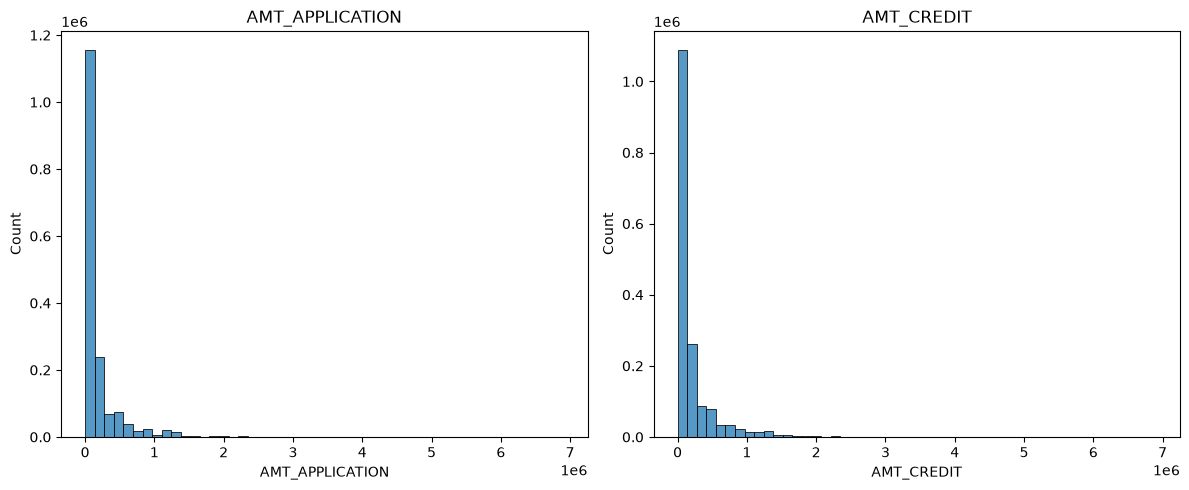

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, col in zip(
    axes,
    ["AMT_APPLICATION", "AMT_CREDIT"]
):

    sns.histplot(
        df_previous_application[col],
        bins=50,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()

#### Observação

* As duas distribuições são semelhantes, então seria bom explorar a relação mais aprofundadamente.
* Os valores estão extremamente concentrados em valores menores com alguns valores altos extremos, indicando que a mediana seria mais importante analisar.
* Os valores solicitados são menores que os valores concedidos em todos os quartis e quantis. 

##### 3.5.1 Correlação entre `AMT_APPLICATION` e `AMT_CREDIT`


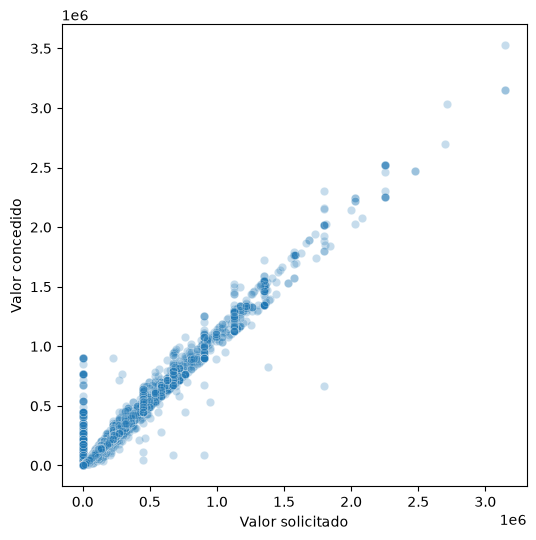

In [152]:
sample = df_previous_application.sample(
    10000,
    random_state=42
)

plt.figure(figsize=(6,6))

sns.scatterplot(
    data=sample,
    x="AMT_APPLICATION",
    y="AMT_CREDIT",
    alpha=0.25
)

plt.xlabel("Valor solicitado")
plt.ylabel("Valor concedido")

plt.show()

In [153]:
df_previous_application[
    ["AMT_APPLICATION", "AMT_CREDIT"]
].corr(method="pearson")

,AMT_APPLICATION,AMT_CREDIT
AMT_APPLICATION,1.00,0.98
AMT_CREDIT,0.98,1.00


##### Observações

* O relacionamento é altamente linear e com uma correlação de 0.98 (Pearson R), fortemente indicando que essas duas variáveis têm relacionamento causal.
* Há uma curiosidade também de valores solicitados de 0 e o valor concedido ser mais alto. Pode gerar erro de divisão por 0 caso criar uma feature de proporção entre as duas variáveis.

#### 3.5.2 Explorando Nova Feature de Proporção `AMT_CREDIT` / `AMT_APPLICATION`

In [154]:
import numpy as np

df_previous_application["APPLICATION_CREDIT_RATIO"] = (
    df_previous_application["AMT_CREDIT"] /
    df_previous_application["AMT_APPLICATION"].replace(0, np.nan)
)

In [155]:
df_previous_application[
    "APPLICATION_CREDIT_RATIO"
].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

count   1277812.00
mean          1.03
std           0.15
min           0.00
1%            0.59
5%            0.80
25%           0.99
50%           1.00
75%           1.11
95%           1.23
99%           1.38
max          20.00
Name: APPLICATION_CREDIT_RATIO, dtype: float64

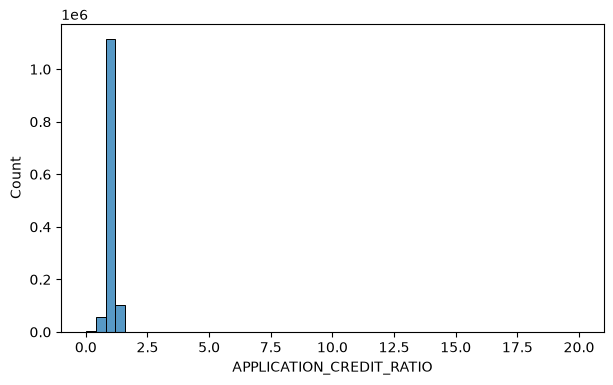

In [156]:
plt.figure(figsize=(7,4))

sns.histplot(
    df_previous_application["APPLICATION_CREDIT_RATIO"],
    bins=50
)

plt.show()

##### Observações

* Como predito, valores de 0 causaram problemas por divisão por 0, então foi necessário remover esses valores. Também será necessário tratar isso na criação desta feature na ABT.
* A mediana é igual a 1, indicando que na maioria dos casos, o valor concedido foi praticamente igual ao valor solicitado.
* 50% das solicitações possuem uma proporção entre 0.99 e 1.12 (1o e 3o quartil), mostrando pouca diferença entre o valor solicitado e o valor concedido.
* Em poucos casos, o valor concedido foi menor que o valor solicitado. 
* Em outros casos, o valor concedido foi superior que o valor solicitado. Essas duas observações talvez contêm mais informações sobre o risco percebido do cliente.

### 3.6 `DAYS_DECISION`

Quantos dias antes da aplicação atual foi tomada a decisão sobre uma solicitação anterior - a recência do relacionamento com a empresa.
Representa a diferença do comportamento de clientes que solicitaram crédito recentemente e os clientes que solicitaram antigamente.

In [157]:
df_previous_application["DAYS_DECISION"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

count   1670214.00
mean       -880.68
std         779.10
min       -2922.00
1%        -2835.00
5%        -2559.00
25%       -1300.00
50%        -581.00
75%        -280.00
95%         -85.00
99%         -14.00
max          -1.00
Name: DAYS_DECISION, dtype: float64

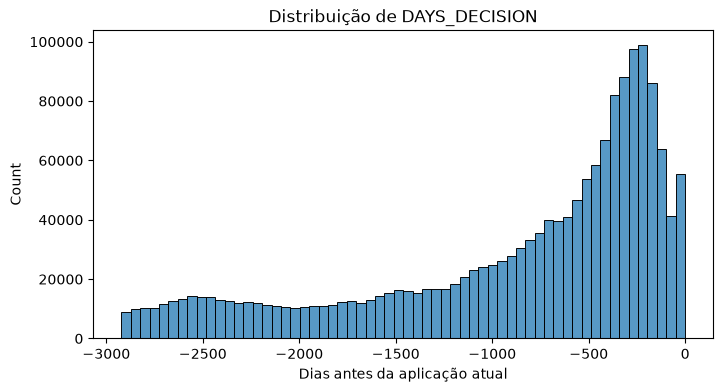

In [158]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_previous_application["DAYS_DECISION"],
    bins=60
)

plt.xlabel("Dias antes da aplicação atual")
plt.title("Distribuição de DAYS_DECISION")

plt.show()

#### Observações

* Varia entre 1 dia antes e 2922 dias (8 anos).
* A mediana de 581 dias mostra que metade das aplicações anteirores ocorreram há menos de ~1.6 anos da solicitação atual.
* Feature engineering: Talvez usar 

### 3.7 `CNT_PAYMENT`

O número de parcelas do empréstimo anterior, ou o prazo do financiamento.

In [159]:
df_previous_application["CNT_PAYMENT"].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

count   1297984.00
mean         16.05
std          14.57
min           0.00
1%            0.00
5%            0.00
25%           6.00
50%          12.00
75%          24.00
95%          48.00
99%          60.00
max          84.00
Name: CNT_PAYMENT, dtype: float64

In [160]:
df_previous_application["CNT_PAYMENT"].isna().sum()

df_previous_application["CNT_PAYMENT"].isna().mean()*100

22.286365699245724

In [161]:
(
    df_previous_application["CNT_PAYMENT"]
    .value_counts()
    .sort_index()
    .head(24)
)

CNT_PAYMENT
0.00     144985
3.00       1100
4.00      26924
5.00       3957
6.00     190461
7.00       1434
8.00      30349
9.00       1236
10.00    141851
11.00       669
12.00    323049
13.00        51
14.00      8253
15.00       904
16.00      5710
17.00        48
18.00     77430
19.00         6
20.00      1805
21.00         3
22.00        37
23.00        27
24.00    137764
26.00        13
Name: count, dtype: int64

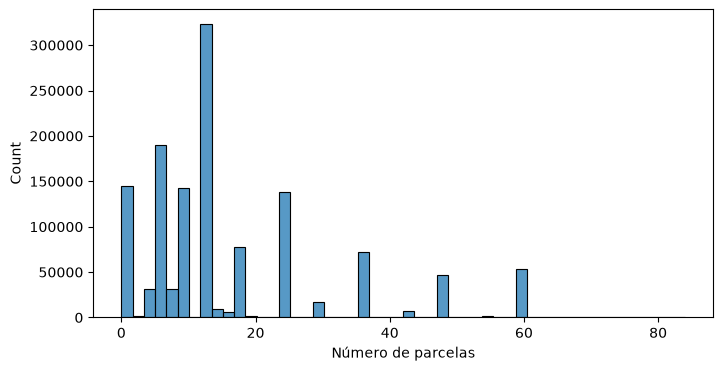

In [162]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_previous_application["CNT_PAYMENT"],
    bins=50
)

plt.xlabel("Número de parcelas")

plt.show()

In [163]:
(
    df_previous_application
    .groupby("NAME_CONTRACT_TYPE")["CNT_PAYMENT"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
NAME_CONTRACT_TYPE,,,,,,,,
Cash loans,461563.00,28.35,16.75,3.00,12.00,24.00,36.00,84.00
Consumer loans,691436.00,11.21,5.71,3.00,6.00,10.00,12.00,72.00
Revolving loans,144985.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
XNA,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Observações

* Alguns valores frequentes - 4 meses, 6 meses, 10 meses, 1 ano, 1.5 anos, 2 anos são alguns valores frequentes.
* Diferentes tipos de contratos demonstram prazos diferentes. Empréstimos de dinheiro tendem a ter prazos mais longos do que empréstimos de consumidor.

### 3.8 RESUMO

1. Usar `SK_ID_CURR` para fazer join com a tabela principal, adicionando mais contexto.
2. Várias colunas com índice alto de nulos, `RATE_INTEREST_PRIMARY`, `RATE_INTEREST_PRIVILEGED`, `DAYS_FIRST_DRAWING`, `RATE_INTEREST_PRIMARY`, `RATE_INTEREST_PRIVILEGED`, `DAYS_FIRST_DRAWING` podem ser dropadas na criação da ABT.
3. Existe uma relação linear extremamente correlacionada entre `AMT_CREDIT` e `AMT_APPLICATION` => Criar nova feature. 
    
    ```python
        df_previous_application["APPLICATION_CREDIT_RATIO"] = (
            df_previous_application["AMT_CREDIT"] /
            df_previous_application["AMT_APPLICATION"].replace(0, np.nan)
        )
    ```

4. O número de parcelas `CNT_PAYMENT` apresenta variação, mas a maioria dos empréstimos concentra-se em prazos de curto e médio prazo, e contratos muito longos são menos frequentes.
5. O histórico de aprovação do cliente `NAME_CONTRACT_STATUS` mostrou-se importante, e podemos criar várias novas features a partir da contagem e % dos aprovados, cancelados, e recusados.

## 4. Resumo Geral

### 4.1 Base principal `application_train`
**307.511 linhas × 122 colunas**

Cada linha representa uma solicitação de crédito, contendo a variável alvo `TARGET` (inadimplência).

- **`TARGET`**: fortemente desbalanceada (~92% adimplentes vs. ~8% inadimplentes), exigindo cuidado na escolha de métricas e técnicas de balanceamento.
- **Variáveis demográficas**: idade, gênero, escolaridade, estado civil, número de filhos e tipo de renda apresentam diferenças entre adimplentes e inadimplentes, sugerindo bom poder preditivo.
  - Clientes mais jovens tendem a ser mais inadimplentes.
  - Mulheres (65% da base) apresentam menor taxa de inadimplência (6,9%) que homens (10,2%).
  - Ensino secundário e superior concentram cerca de 95% da base.
  - Solteiros e pessoas em união civil apresentam maior inadimplência.
  - Clientes sem filhos são maioria (~70%), com leve aumento do risco conforme cresce o número de filhos.
  - O tipo de renda também apresenta diferenças entre categorias.
- **Variáveis financeiras** (`AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE`): distribuições bastante assimétricas, com presença de outliers. Individualmente possuem baixo poder preditivo, mas razões entre elas (*ratios*) tendem a ser mais informativas.
- **Emprego**: `DAYS_EMPLOYED` utiliza dias negativos (necessitando conversão para anos), possui muitos valores ausentes relacionados à falta de histórico e indica menor tempo de emprego entre inadimplentes. `OCCUPATION_TYPE` apresenta 31% de nulos, mas demonstra potencial preditivo. `ORGANIZATION_TYPE` possui alta cardinalidade (58 categorias).
- **Habitação**: posse de imóvel tem pouco impacto na inadimplência, enquanto `NAME_HOUSING_TYPE` apresenta diferenças entre categorias (como aluguel e morar com os pais).
- **Scores externos** (`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`): variáveis com forte poder preditivo; clientes inadimplentes apresentam scores sistematicamente menores.

### 4.2 Base suplementar `bureau`
**1.716.428 linhas × 17 colunas**

Histórico de créditos do cliente em outras instituições financeiras.

- A maioria dos clientes possui entre 1 e 8 registros, embora existam casos com dezenas de créditos.
- `CREDIT_ACTIVE`: aproximadamente 630 mil créditos ativos e 1,08 milhão encerrados.
- `CREDIT_TYPE`: predominância de *Consumer Credit* e *Credit Card*.
- `CREDIT_CURRENCY`: praticamente uma única moeda.
- Variáveis temporais (`DAYS_CREDIT`, `DAYS_CREDIT_ENDDATE`, `DAYS_ENDDATE_FACT`) seguem a convenção de dias negativos e fornecem informações sobre recência e duração do histórico de crédito.
- Variáveis monetárias (`AMT_CREDIT_SUM`, `AMT_CREDIT_SUM_DEBT`, `AMT_CREDIT_SUM_OVERDUE`, `AMT_ANNUITY`) tendem a ser mais úteis quando agregadas por `SK_ID_CURR`.

### 4.3 Base suplementar `previous_application`
**1,670,214 linhas × 37 colunas**

Histórico de solicitações anteriores realizadas pelo cliente na própria instituição.

- Em média, cada cliente possui cerca de cinco solicitações anteriores.
- Diversas colunas apresentam elevado percentual de valores ausentes, sendo candidatas à remoção.
- `NAME_CONTRACT_STATUS`: cerca de 62% das solicitações foram aprovadas; o restante foi cancelado ou recusado.
- `NAME_CONTRACT_TYPE`: *Cash Loans* e *Consumer Loans* representam aproximadamente 90% dos registros.
- `AMT_APPLICATION` e `AMT_CREDIT` possuem correlação muito alta (0,98), indicando possível colinearidade.
- `DAYS_DECISION`: mediana de 581 dias desde a decisão da solicitação anterior (~1,6 anos).
- `CNT_PAYMENT`: prazos concentrados em valores comuns (4, 6, 10, 12, 18 e 24 meses), sendo os *Cash Loans* geralmente mais longos que os *Consumer Loans*.